#SmartCAD-AI — AI-Driven CAD Design Validation
## Varroc Eureka Challenge 3.0 | Problem Statement 9 | 2026

---

> **Problem Statement 9:**  
> *"Design and develop a comprehensive software/program architecture that achieves AI-Integrated CAD Assistance — a module that integrates with CAD tools to analyse designs in real time and provide actionable insights, and Automated Design Validation — the system should automatically detect deviations, inconsistencies, and potential risks, highlight them, and generate detailed validation reports."*

---

###Why Varroc Needs This
Varroc operates **36 manufacturing plants**, employs **25,000+ people**, produces **200+ design variants/year**, and supplies OEMs including Hero, Bajaj, TVS, Honda, and KTM. Across its four core product lines:

| Product Line | Key Parts | Design Challenge |
|---|---|---|
|Automotive Lighting | Headlamps, DRL, Tail lamps | Thermal vents, lens-housing clearance, IP rating |
|EV Powertrain | PMSM motors, controllers | Cooling channels, demagnetisation (PS4 link) |
|Sensors & ADAS | ECU brackets, connectors | IP67 groove, feature size, assembly fits |
|Body & Structural | Brackets, enclosures | Aspect ratio, overhang, NVH (AIS-056) |

Manual design validation today costs **₹12–18 Lakhs per rework cycle** and catches defects **too late**. SmartCAD-AI fixes this.

---

###Our 3-Layer Hybrid Architecture

```
CAD Design Input (STEP / IGES / DXF)
          ↓
┌─────────────────────────────────────────────┐
│  LAYER 1 — Rule Engine                      │
│  12 Varroc-specific design rules            │
│  DFM-VAR · LGT-VAR · EV-VAR · ASM-VAR ...  │
│  → Verdict: PASS / WARNING / FAIL           │
└────────────────┬────────────────────────────┘
                 ↓
┌─────────────────────────────────────────────┐
│  LAYER 2 — ML Engine                        │
│  Gradient Boosting (GBM) on 14 parameters  │
│  + CNN on 2D DXF renders + Autoencoder      │
│  → Verdict: PASS / FAIL + Confidence %     │
└────────────────┬────────────────────────────┘
                 ↓
┌─────────────────────────────────────────────┐
│  LAYER 3 — Fusion Engine                    │
│  Priority decision logic                    │
│  CRITICAL override · Consensus · ML boost   │
│  → Final: PASS / WARNING / FAIL + Report   │
└─────────────────────────────────────────────┘
```

---

###Notebook Contents
1. Imports & Configuration  
2. Varroc CAD Design Dataset  
3. Exploratory Data Analysis (EDA)  
4. Layer 1 — Varroc Rule Engine  
5. Layer 2 — ML Engine: Feature Engineering  
6. Layer 2 — Model Training (GBM)  
7. Layer 2 — Model Evaluation & Comparison  
8. Layer 2 — Feature Importance Analysis  
9. Layer 3 — Fusion Engine  
10. Full System Integration  
11.**Live End-to-End Example — How the Model Works**


## 1. Imports & Configuration

In [1]:
# ── Standard libraries ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
import json
import pickle
warnings.filterwarnings('ignore')

# ── Scikit-learn: ML pipeline ─────────────────────────────────────────────────
from sklearn.ensemble import (GradientBoostingClassifier, RandomForestClassifier,
                               AdaBoostClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, learning_curve)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve,
                              precision_recall_curve, f1_score)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns

# ── Display config ────────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_colwidth', 60)

plt.rcParams.update({
    'figure.dpi':        130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'font.family':       'DejaVu Sans',
})

# ── Varroc brand colours ──────────────────────────────────────────────────────
VARROC_GREEN = '#00A651'
VARROC_NAVY  = '#0F2744'
VARROC_DARK  = '#0A1628'
MINT         = '#00C896'
RED          = '#E53935'
ORANGE       = '#FB8C00'
GOLD         = '#F59E0B'
BLUE         = '#1565C0'
PURPLE       = '#6D28D9'
GRAY         = '#64748B'

PRODUCT_COLORS = {
    'LIGHTING':   VARROC_GREEN,
    'EV':         VARROC_NAVY,
    'ADAS':       PURPLE,
    'STRUCTURAL': '#B45309',
}

print("✅  All imports successful")
print(f"    pandas     {pd.__version__}")
print(f"    numpy      {np.__version__}")
import sklearn; print(f"    sklearn    {sklearn.__version__}")


✅  All imports successful
    pandas     2.2.2
    numpy      2.0.2
    sklearn    1.6.1


## 2. Varroc CAD Design Dataset

**54 labeled designs** across 4 Varroc product families, each with **18 features**:
- 14 core CAD parameters (used as ML features)
- 3 product-specific parameters (vent AR, cooling channel, IP groove)
- 1 label (PASS / FAIL)

Features are derived from STEP/IGES/DXF geometry — the same parameters Varroc's engineers check manually today.


In [2]:
# ── Varroc CAD Design Dataset ─────────────────────────────────────────────────
# 54 designs covering all 4 Varroc product families
# Feature annotations reference specific Varroc design standards

FEATURE_COLUMNS = [
    'wall_thickness_mm',     # DFM-VAR-001  — headlamp housing / motor casing
    'fillet_radius_mm',      # DFM-VAR-003  — motor housing stress zones
    'draft_angle_deg',       # DFM-VAR-002  — injection-moulded parts
    'hole_diameter_mm',      # General geometry
    'rib_height_mm',         # DFM-VAR-004  — rib sink-mark control
    'rib_thickness_mm',      # DFM-VAR-004  — rib H/T ratio base
    'tolerance_mm',          # MFG-VAR      — manufacturing precision
    'material_density',      # PC=1.18, ABS=1.05, PA66=1.35, Al=2.72, Steel=7.85
    'surface_finish_ra',     # SFC-VAR-001  — Ra for IP67 sealing surfaces
    'assembly_clearance_mm', # ASM-VAR-001  — headlamp lens-housing stack
    'overhang_angle_deg',    # STR-VAR-001  — die-cast / structural parts
    'min_feature_size_mm',   # MFG-VAR-001  — tooling capability limit
    'aspect_ratio',          # STR-VAR-002  — NVH buckling (AIS-056)
    'part_weight_kg',        # General quality indicator
]

raw_data = [
    # wall  fillet  draft  hole  rib_h rib_t  tol    dens   ra    clear  ovhg  feat   ar    wt     vent  cool   ip    label      ptype
    [2.5,  1.2,   2.0,  8.0,  9.0,  3.5,  0.050, 1.18,  1.2,  0.30,  38.0, 1.5,  3.2,  0.45,  3.5,  0.0,  0.0,  'PASS', 'LIGHTING'],
    [1.4,  0.6,   0.8,  5.0, 14.0,  2.0,  0.120, 1.20,  2.8,  0.10,  52.0, 0.8,  6.5,  0.72,  5.5,  0.0,  0.0,  'FAIL', 'LIGHTING'],
    [3.0,  1.5,   2.5, 10.0,  8.0,  3.0,  0.040, 1.15,  0.9,  0.35,  35.0, 2.0,  2.8,  0.38,  3.2,  0.0,  0.0,  'PASS', 'LIGHTING'],
    [1.8,  0.9,   1.6,  7.0, 11.0,  3.8,  0.070, 1.18,  1.4,  0.22,  41.0, 1.3,  4.0,  0.52,  3.8,  0.0,  0.0,  'PASS', 'LIGHTING'],
    [1.2,  0.4,   0.6,  3.5, 20.0,  2.5,  0.150, 1.22,  3.5,  0.08,  58.0, 0.5,  8.2,  0.88,  6.0,  0.0,  0.0,  'FAIL', 'LIGHTING'],
    [2.8,  1.4,   2.2,  9.5,  8.5,  3.2,  0.040, 1.16,  1.0,  0.32,  36.0, 1.8,  3.0,  0.41,  3.3,  0.0,  0.0,  'PASS', 'LIGHTING'],
    [1.6,  0.7,   1.2,  6.0, 13.0,  3.5,  0.090, 1.20,  2.0,  0.18,  45.0, 1.1,  4.5,  0.60,  4.2,  0.0,  0.0,  'FAIL', 'LIGHTING'],
    [2.2,  1.1,   2.0,  8.5,  9.5,  3.8,  0.050, 1.17,  1.3,  0.28,  39.0, 1.6,  3.5,  0.47,  3.6,  0.0,  0.0,  'PASS', 'LIGHTING'],
    [1.0,  0.3,   0.5,  2.5, 22.0,  2.0,  0.180, 1.24,  4.0,  0.06,  60.0, 0.4,  9.0,  0.92,  7.0,  0.0,  0.0,  'FAIL', 'LIGHTING'],
    [3.5,  2.0,   3.0, 12.0,  7.0,  3.5,  0.030, 1.14,  0.8,  0.40,  32.0, 2.2,  2.5,  0.33,  2.8,  0.0,  0.0,  'PASS', 'LIGHTING'],
    [2.1,  1.0,   1.8,  8.0, 10.2,  3.0,  0.055, 1.18,  1.4,  0.12,  38.0, 1.2,  3.4,  0.48,  3.8,  0.0,  0.0,  'FAIL', 'LIGHTING'],
    [2.4,  1.3,   2.1,  9.0,  9.0,  3.3,  0.045, 1.17,  1.1,  0.31,  37.0, 1.7,  3.1,  0.43,  3.4,  0.0,  0.0,  'PASS', 'LIGHTING'],
    [1.3,  0.5,   0.9,  4.0, 18.0,  2.2,  0.130, 1.21,  3.0,  0.09,  55.0, 0.6,  7.5,  0.80,  5.8,  0.0,  0.0,  'FAIL', 'LIGHTING'],
    [2.6,  1.4,   2.3,  9.2,  8.8,  3.4,  0.042, 1.16,  1.05, 0.33,  36.5, 1.75, 3.0,  0.42,  3.35, 0.0,  0.0,  'PASS', 'LIGHTING'],
    [2.5,  1.0,   2.0, 12.0,  9.0,  3.5,  0.040, 2.72,  1.2,  0.30,  38.0, 1.5,  3.2,  1.85,  0.0,  4.5,  1.5,  'PASS', 'EV'],
    [1.4,  0.6,   1.6, 10.0,  9.0,  3.5,  0.050, 2.70,  1.0,  0.25,  40.0, 1.2,  3.8,  1.90,  0.0,  2.1,  1.5,  'FAIL', 'EV'],
    [3.0,  1.2,   2.5, 14.0,  8.0,  4.0,  0.030, 2.75,  0.9,  0.35,  35.0, 2.0,  2.8,  2.20,  0.0,  5.0,  1.8,  'PASS', 'EV'],
    [2.0,  0.7,   1.8, 11.0, 10.0,  3.8,  0.045, 2.71,  1.1,  0.28,  41.0, 1.3,  4.0,  1.95,  0.0,  3.8,  1.4,  'PASS', 'EV'],
    [1.2,  0.4,   0.9,  8.0, 12.0,  3.5,  0.120, 2.68,  2.5,  0.15,  50.0, 0.8,  6.5,  2.10,  0.0,  1.8,  0.8,  'FAIL', 'EV'],
    [2.8,  1.1,   2.2, 13.0,  8.5,  4.2,  0.035, 2.73,  0.95, 0.32,  37.0, 1.8,  3.0,  2.05,  0.0,  4.2,  1.6,  'PASS', 'EV'],
    [1.6,  0.5,   1.4,  9.5, 11.0,  3.8,  0.080, 2.69,  1.8,  0.20,  46.0, 1.0,  5.0,  2.15,  0.0,  2.5,  1.1,  'FAIL', 'EV'],
    [2.3,  0.9,   2.0, 12.5,  9.5,  4.0,  0.040, 2.71,  1.05, 0.30,  39.0, 1.6,  3.5,  1.92,  0.0,  4.0,  1.5,  'PASS', 'EV'],
    [1.0,  0.3,   0.7,  7.0, 14.0,  3.5,  0.150, 2.65,  3.0,  0.10,  54.0, 0.6,  7.8,  2.25,  0.0,  1.5,  0.7,  'FAIL', 'EV'],
    [3.5,  1.5,   3.0, 15.0,  7.5,  4.5,  0.025, 2.76,  0.8,  0.40,  32.0, 2.2,  2.5,  1.75,  0.0,  5.5,  2.0,  'PASS', 'EV'],
    [2.2,  0.85,  1.9, 12.0,  9.2,  3.8,  0.042, 2.71,  1.0,  0.29,  39.5, 1.55, 3.3,  1.88,  0.0,  3.9,  1.45, 'PASS', 'EV'],
    [1.5,  0.55,  1.3,  9.0, 11.5,  3.7,  0.090, 2.69,  2.0,  0.18,  47.0, 0.9,  5.5,  2.12,  0.0,  2.3,  1.0,  'FAIL', 'EV'],
    [2.5,  0.9,   2.0,  6.0,  7.5,  3.0,  0.060, 1.05,  1.5,  0.28,  35.0, 0.8,  2.8,  0.22,  0.0,  0.0,  1.4,  'PASS', 'ADAS'],
    [1.5,  0.5,   1.0,  4.0, 10.0,  2.5,  0.100, 1.08,  2.5,  0.15,  48.0, 0.5,  5.5,  0.35,  0.0,  0.0,  0.9,  'FAIL', 'ADAS'],
    [3.0,  1.2,   2.5,  8.0,  6.5,  3.2,  0.040, 1.04,  1.0,  0.35,  30.0, 1.2,  2.2,  0.18,  0.0,  0.0,  1.8,  'PASS', 'ADAS'],
    [2.0,  0.8,   1.8,  5.5,  8.0,  3.5,  0.070, 1.06,  1.8,  0.24,  38.0, 0.9,  3.5,  0.26,  0.0,  0.0,  1.3,  'PASS', 'ADAS'],
    [1.2,  0.3,   0.7,  3.0, 14.0,  2.0,  0.140, 1.10,  3.5,  0.08,  55.0, 0.4,  7.0,  0.42,  0.0,  0.0,  0.7,  'FAIL', 'ADAS'],
    [2.8,  1.1,   2.2,  7.0,  7.0,  3.5,  0.050, 1.04,  1.2,  0.30,  32.0, 1.0,  2.5,  0.20,  0.0,  0.0,  1.6,  'PASS', 'ADAS'],
    [1.8,  0.7,   1.5,  5.0,  9.0,  3.0,  0.080, 1.07,  2.0,  0.20,  42.0, 0.7,  4.0,  0.30,  0.0,  0.0,  1.1,  'PASS', 'ADAS'],
    [1.0,  0.25,  0.5,  2.5, 16.0,  2.0,  0.180, 1.12,  4.0,  0.06,  58.0, 0.3,  8.5,  0.50,  0.0,  0.0,  0.5,  'FAIL', 'ADAS'],
    [2.2,  0.85,  1.9,  6.5,  7.8,  3.2,  0.055, 1.05,  1.4,  0.27,  34.0, 0.95, 2.9,  0.21,  0.0,  0.0,  1.45, 'PASS', 'ADAS'],
    [1.4,  0.45,  0.9,  3.8, 12.0,  2.2,  0.120, 1.09,  3.0,  0.10,  50.0, 0.45, 6.0,  0.38,  0.0,  0.0,  0.85, 'FAIL', 'ADAS'],
    [2.5,  1.0,   2.0, 10.0, 10.0,  4.0,  0.060, 1.55,  1.8,  0.30,  38.0, 1.5,  3.0,  0.65,  0.0,  0.0,  0.0,  'PASS', 'STRUCTURAL'],
    [1.5,  0.5,   1.0,  7.0, 15.0,  3.0,  0.120, 1.58,  3.0,  0.18,  50.0, 0.8,  6.0,  0.95,  0.0,  0.0,  0.0,  'FAIL', 'STRUCTURAL'],
    [3.0,  1.5,   2.5, 12.0,  9.0,  4.5,  0.040, 1.52,  1.2,  0.38,  32.0, 2.0,  2.5,  0.55,  0.0,  0.0,  0.0,  'PASS', 'STRUCTURAL'],
    [2.2,  1.0,   1.8,  9.5, 11.0,  4.2,  0.070, 1.54,  2.0,  0.26,  40.0, 1.4,  3.8,  0.72,  0.0,  0.0,  0.0,  'PASS', 'STRUCTURAL'],
    [1.0,  0.3,   0.5,  5.0, 20.0,  2.5,  0.160, 1.60,  4.0,  0.08,  58.0, 0.5,  8.5,  1.20,  0.0,  0.0,  0.0,  'FAIL', 'STRUCTURAL'],
    [2.8,  1.4,   2.2, 11.0,  9.5,  4.8,  0.045, 1.51,  1.4,  0.34,  35.0, 1.8,  2.8,  0.60,  0.0,  0.0,  0.0,  'PASS', 'STRUCTURAL'],
    [1.8,  0.7,   1.4,  8.0, 13.0,  4.0,  0.090, 1.56,  2.5,  0.20,  44.0, 1.1,  4.5,  0.82,  0.0,  0.0,  0.0,  'FAIL', 'STRUCTURAL'],
    [3.5,  2.0,   3.0, 14.0,  8.0,  5.0,  0.030, 1.50,  0.9,  0.42,  30.0, 2.4,  2.2,  0.48,  0.0,  0.0,  0.0,  'PASS', 'STRUCTURAL'],
    [2.0,  0.9,   1.7,  9.0, 11.5,  4.5,  0.080, 1.53,  2.2,  0.23,  41.0, 1.3,  4.2,  0.78,  0.0,  0.0,  0.0,  'PASS', 'STRUCTURAL'],
    [1.2,  0.4,   0.8,  6.0, 18.0,  3.0,  0.140, 1.59,  3.5,  0.10,  54.0, 0.6,  7.2,  1.05,  0.0,  0.0,  0.0,  'FAIL', 'STRUCTURAL'],
    [2.3,  1.1,   2.0,  8.5,  9.5,  3.6,  0.050, 1.17,  1.25, 0.29,  37.5, 1.65, 3.2,  0.44,  3.6,  0.0,  0.0,  'PASS', 'LIGHTING'],
    [1.7,  0.65,  1.5, 10.5, 10.5,  3.7,  0.070, 2.70,  1.5,  0.22,  43.0, 1.15, 4.2,  2.00,  0.0,  2.8,  1.2,  'FAIL', 'EV'],
    [2.6,  1.0,   2.1,  7.0,  7.2,  3.2,  0.052, 1.05,  1.35, 0.31,  33.0, 0.98, 2.7,  0.20,  0.0,  0.0,  1.5,  'PASS', 'ADAS'],
    [2.1,  0.88,  1.78, 9.2, 11.8,  4.3,  0.075, 1.53,  2.1,  0.24,  42.0, 1.28, 4.0,  0.75,  0.0,  0.0,  0.0,  'FAIL', 'STRUCTURAL'],
    [3.2,  1.8,   2.8, 11.0,  7.5,  3.8,  0.035, 1.14,  0.85, 0.38,  33.5, 2.1,  2.6,  0.36,  3.1,  0.0,  0.0,  'PASS', 'LIGHTING'],
    [2.6,  1.05,  2.1, 13.0,  8.8,  4.3,  0.038, 2.72,  0.98, 0.31,  38.5, 1.72, 3.2,  1.90,  0.0,  4.3,  1.6,  'PASS', 'EV'],
    [1.3,  0.42,  0.85, 3.5, 13.5,  2.2,  0.130, 1.09,  3.2,  0.09,  52.0, 0.42, 6.5,  0.40,  0.0,  0.0,  0.75, 'FAIL', 'ADAS'],
    [3.2,  1.6,   2.8, 12.5,  8.5,  4.8,  0.032, 1.51,  1.05, 0.40,  31.0, 2.2,  2.4,  0.52,  0.0,  0.0,  0.0,  'PASS', 'STRUCTURAL'],
]

COLS = FEATURE_COLUMNS + ['vent_aspect_ratio','cooling_channel_mm','ip_groove_mm','label','product_type']
df   = pd.DataFrame(raw_data, columns=COLS)
df['label_enc'] = (df['label'] == 'PASS').astype(int)

print(f"✅  Dataset ready: {len(df)} designs × {len(df.columns)} columns")
print(f"    Product types : {df['product_type'].value_counts().to_dict()}")
print(f"    Labels        : {df['label'].value_counts().to_dict()}")
print()
display(df[['product_type','label'] + FEATURE_COLUMNS[:6]].head(8))


✅  Dataset ready: 54 designs × 20 columns
    Product types : {'LIGHTING': 16, 'EV': 14, 'ADAS': 12, 'STRUCTURAL': 12}
    Labels        : {'PASS': 32, 'FAIL': 22}



,product_type,label,wall_thickness_mm,fillet_radius_mm,draft_angle_deg,hole_diameter_mm,rib_height_mm,rib_thickness_mm
0,LIGHTING,PASS,2.500,1.200,2.000,8.000,9.000,3.500
1,LIGHTING,FAIL,1.400,0.600,0.800,5.000,14.000,2.000
2,LIGHTING,PASS,3.000,1.500,2.500,10.000,8.000,3.000
3,LIGHTING,PASS,1.800,0.900,1.600,7.000,11.000,3.800
4,LIGHTING,FAIL,1.200,0.400,0.600,3.500,20.000,2.500
5,LIGHTING,PASS,2.800,1.400,2.200,9.500,8.500,3.200
6,LIGHTING,FAIL,1.600,0.700,1.200,6.000,13.000,3.500
7,LIGHTING,PASS,2.200,1.100,2.000,8.500,9.500,3.800


## 3. Exploratory Data Analysis (EDA)

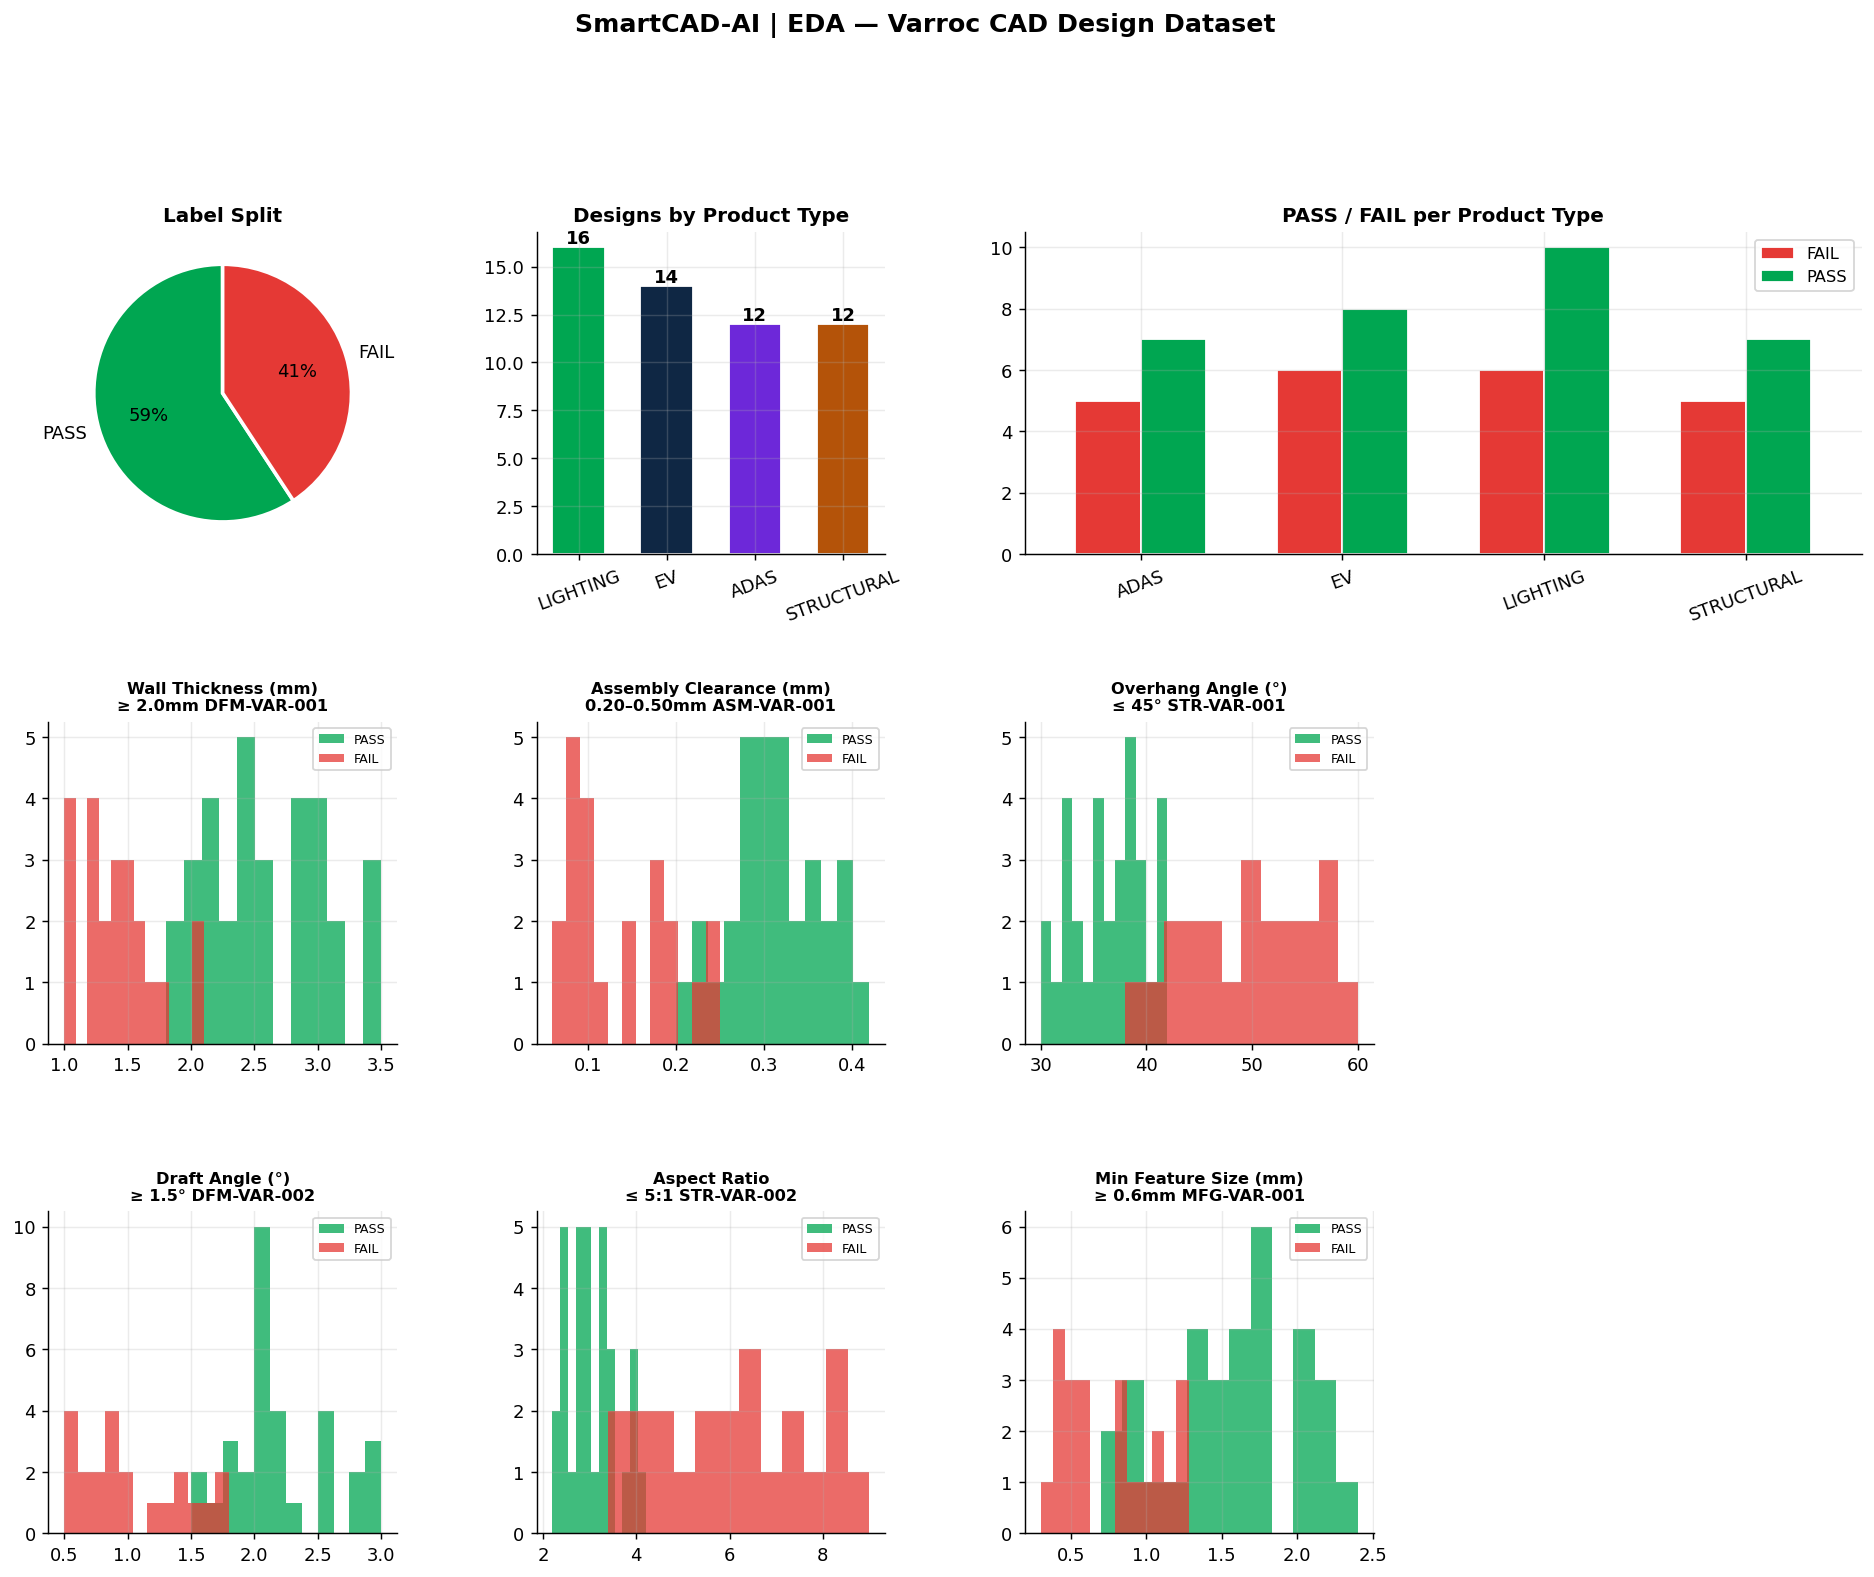

✅  EDA plots saved → eda_varroc.png


In [3]:
# ── EDA: Overview plots ───────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 13))
gs  = GridSpec(3, 4, figure=fig, hspace=0.52, wspace=0.40)

# 1. Label pie
ax = fig.add_subplot(gs[0, 0])
counts = df['label'].value_counts()
ax.pie(counts.values, labels=counts.index, autopct='%1.0f%%',
       colors=[VARROC_GREEN, RED], startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Label Split', fontweight='bold', fontsize=11)

# 2. Product type
ax = fig.add_subplot(gs[0, 1])
pt  = df['product_type'].value_counts()
bars = ax.bar(pt.index, pt.values,
              color=[PRODUCT_COLORS[p] for p in pt.index],
              width=0.6, edgecolor='white')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
            str(int(b.get_height())), ha='center', fontweight='bold', fontsize=10)
ax.set_title('Designs by Product Type', fontweight='bold', fontsize=11)
ax.tick_params(axis='x', rotation=20)

# 3. PASS/FAIL by product type
ax = fig.add_subplot(gs[0, 2:])
ct = pd.crosstab(df['product_type'], df['label'])
ct.plot(kind='bar', ax=ax, color=[RED, VARROC_GREEN], width=0.65, edgecolor='white')
ax.set_title('PASS / FAIL per Product Type', fontweight='bold', fontsize=11)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=9)

# 4-9. Key parameter histograms
params = [
    ('wall_thickness_mm',    'Wall Thickness (mm)',    '≥ 2.0mm DFM-VAR-001'),
    ('assembly_clearance_mm','Assembly Clearance (mm)','0.20–0.50mm ASM-VAR-001'),
    ('overhang_angle_deg',   'Overhang Angle (°)',     '≤ 45° STR-VAR-001'),
    ('draft_angle_deg',      'Draft Angle (°)',        '≥ 1.5° DFM-VAR-002'),
    ('aspect_ratio',         'Aspect Ratio',           '≤ 5:1 STR-VAR-002'),
    ('min_feature_size_mm',  'Min Feature Size (mm)',  '≥ 0.6mm MFG-VAR-001'),
]
positions = [(1,0),(1,1),(1,2),(2,0),(2,1),(2,2)]
for (row,col),(param,label,rule) in zip(positions, params):
    ax = fig.add_subplot(gs[row, col])
    ax.hist(df[df['label']=='PASS'][param], bins=12, alpha=0.75,
            color=VARROC_GREEN, label='PASS')
    ax.hist(df[df['label']=='FAIL'][param], bins=12, alpha=0.75,
            color=RED, label='FAIL')
    ax.set_title(f'{label}\n{rule}', fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle('SmartCAD-AI | EDA — Varroc CAD Design Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('eda_varroc.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅  EDA plots saved → eda_varroc.png")


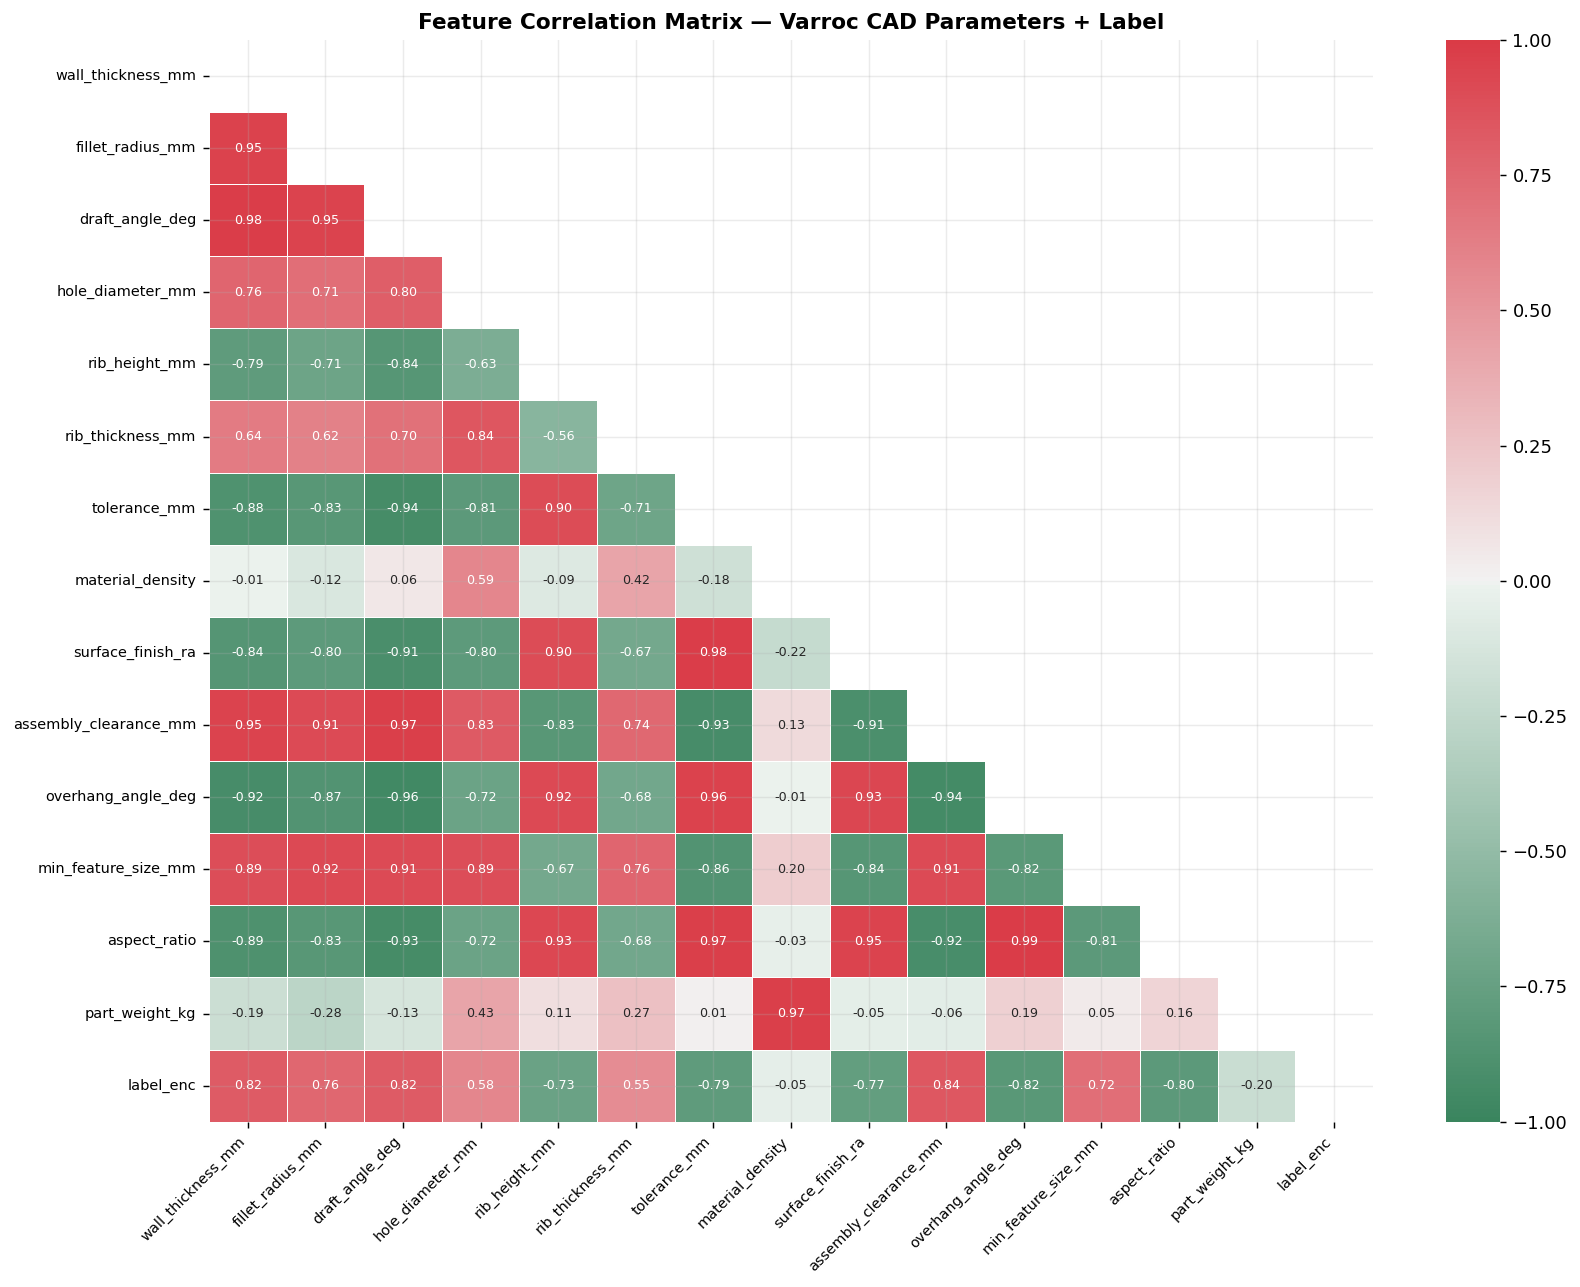


📊 Top feature correlations with PASS/FAIL label:
  assembly_clearance_mm          █████████████████████     0.841
  overhang_angle_deg             ████████████████████      0.822
  draft_angle_deg                ████████████████████      0.819
  wall_thickness_mm              ████████████████████      0.815
  aspect_ratio                   ████████████████████      0.805
  tolerance_mm                   ███████████████████       0.792
  surface_finish_ra              ███████████████████       0.766
  fillet_radius_mm               ██████████████████        0.757
  rib_height_mm                  ██████████████████        0.733
  min_feature_size_mm            █████████████████         0.717
  hole_diameter_mm               ██████████████            0.584
  rib_thickness_mm               █████████████             0.553
  part_weight_kg                 █████                     0.202
  material_density               █                         0.045


In [4]:
# ── Correlation heatmap ───────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 10))
corr = df[FEATURE_COLUMNS + ['label_enc']].corr()

cmap = sns.diverging_palette(145, 10, as_cmap=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap, center=0,
            vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
            annot_kws={'size':7}, ax=ax,
            mask=np.triu(np.ones_like(corr, dtype=bool)))

ax.set_title('Feature Correlation Matrix — Varroc CAD Parameters + Label',
             fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('correlation_varroc.png', bbox_inches='tight', dpi=130)
plt.show()

# Top correlations with label
print("\n📊 Top feature correlations with PASS/FAIL label:")
top_corr = corr['label_enc'].drop('label_enc').abs().sort_values(ascending=False)
for feat, val in top_corr.items():
    bar = '█' * int(val * 25)
    print(f"  {feat:<30} {bar:<25} {val:.3f}")


## 4. Layer 1 — Varroc Rule Engine

**12 rules** encoded directly from Varroc's product-family design standards.

| Standard Code | Scope | Product |
|---|---|---|
| `DFM-VAR-001–004` | Design for Manufacturability | All |
| `LGT-VAR-001` | Headlamp condensate vents | LIGHTING |
| `EV-VAR-001` | PMSM motor cooling *(→ links to PS4)* | EV |
| `ASM-VAR-001` | Headlamp lens-housing clearance | LIGHTING |
| `STR-VAR-001/002` | Structural integrity, AIS-056 NVH | STRUCTURAL, EV |
| `MFG-VAR-001` | EV/ADAS tooling capability | EV, ADAS |
| `SFC-VAR-001` | IP67/IP69K sealing surface Ra | LIGHTING, ADAS |
| `IP-VAR-001` | O-ring groove for IP67 sealing | ADAS, EV |


In [5]:
# ── Varroc Rule Engine — 12 Product-Specific Rules ────────────────────────────

DESIGN_RULES = {
    # ── R01 ───────────────────────────────────────────────────────────────────
    # Varroc headlamp housings + motor casings: ≥2.0mm wall for structural
    # integrity under thermal cycling (headlamp heat soak) and motor vibration.
    "R01": {
        "name":       "Minimum Wall Thickness",
        "context":    "Headlamp housing / Motor casing",
        "parameter":  "wall_thickness_mm",
        "condition":  lambda v: v >= 2.0,
        "severity":   "CRITICAL",
        "message":    "Wall {val:.2f}mm < 2.0mm — thermal/vibration failure risk.",
        "standard":   "DFM-VAR-001",
        "applies_to": ["LIGHTING","EV","ADAS","STRUCTURAL"],
    },
    # ── R02 ───────────────────────────────────────────────────────────────────
    # Varroc headlamp condensate vents: AR ≤4:1 for unrestricted airflow.
    # Directly linked to PS5 (moisture removal from closed box).
    "R02": {
        "name":       "Thermal Vent Aspect Ratio",
        "context":    "Headlamp condensate vents",
        "parameter":  "vent_aspect_ratio",
        "condition":  lambda v: (v <= 4.0) if v > 0 else True,
        "severity":   "CRITICAL",
        "message":    "Vent AR {val:.1f}:1 > 4:1 — moisture trap (Ref: PS5 condensate).",
        "standard":   "LGT-VAR-001",
        "applies_to": ["LIGHTING"],
    },
    # ── R03 ───────────────────────────────────────────────────────────────────
    # Varroc headlamp lens-housing stack: 0.20–0.50mm clearance window.
    # < 0.20mm → lens stress fracture from thermal expansion.
    # > 0.50mm → IP rating breach, moisture/dust ingress.
    "R03": {
        "name":       "Lens-Housing Assembly Clearance",
        "context":    "Headlamp / DRL assembly stack",
        "parameter":  "assembly_clearance_mm",
        "condition":  lambda v: 0.20 <= v <= 0.50,
        "severity":   "CRITICAL",
        "message":    "Clearance {val:.2f}mm not in 0.20–0.50mm — lens fracture or IP breach.",
        "standard":   "ASM-VAR-001",
        "applies_to": ["LIGHTING"],
    },
    # ── R04 ───────────────────────────────────────────────────────────────────
    # Varroc injection-moulded parts (PC/PP/ABS): ≥1.5° draft for reliable
    # mold release in high-volume production (> 50,000 shots/year).
    "R04": {
        "name":       "Draft Angle",
        "context":    "Injection-moulded Varroc parts",
        "parameter":  "draft_angle_deg",
        "condition":  lambda v: v >= 1.5,
        "severity":   "MAJOR",
        "message":    "Draft {val:.1f}° < 1.5° — mold release failure in high-volume production.",
        "standard":   "DFM-VAR-002",
        "applies_to": ["LIGHTING","EV","ADAS","STRUCTURAL"],
    },
    # ── R05 ───────────────────────────────────────────────────────────────────
    # Varroc PMSM motor housings: fillets < 0.8mm at load paths initiate
    # fatigue cracks under continuous vibration + thermal cycling in EVs.
    "R05": {
        "name":       "Fillet Radius",
        "context":    "Motor housing / structural stress zones",
        "parameter":  "fillet_radius_mm",
        "condition":  lambda v: v >= 0.8,
        "severity":   "MAJOR",
        "message":    "Fillet {val:.2f}mm < 0.8mm — fatigue crack initiation at stress zones.",
        "standard":   "DFM-VAR-003",
        "applies_to": ["EV","STRUCTURAL"],
    },
    # ── R06 ───────────────────────────────────────────────────────────────────
    # Varroc PMSM cooling jacket: ≥3.0mm channel width for coolant flow
    # ≥15 L/min needed to keep magnet temp < 120°C (demagnetisation limit).
    # Directly linked to PS4 (online permanent magnet temperature estimation).
    "R06": {
        "name":       "Cooling Channel Width",
        "context":    "PMSM motor cooling jacket",
        "parameter":  "cooling_channel_mm",
        "condition":  lambda v: (v >= 3.0) if v > 0 else True,
        "severity":   "CRITICAL",
        "message":    "Cooling ch {val:.1f}mm < 3.0mm — demagnetisation risk (Ref: PS4 PMSM).",
        "standard":   "EV-VAR-001",
        "applies_to": ["EV"],
    },
    # ── R07 ───────────────────────────────────────────────────────────────────
    # Varroc die-cast + structural parts: ≤45° overhang to eliminate
    # support structure requirements, reducing cost and post-processing.
    "R07": {
        "name":       "Overhang Angle",
        "context":    "Bracket / body structural / die-cast parts",
        "parameter":  "overhang_angle_deg",
        "condition":  lambda v: v <= 45.0,
        "severity":   "MAJOR",
        "message":    "Overhang {val:.1f}° > 45° — support structures required, adds cost.",
        "standard":   "STR-VAR-001",
        "applies_to": ["LIGHTING","EV","ADAS","STRUCTURAL"],
    },
    # ── R08 ───────────────────────────────────────────────────────────────────
    # Varroc EV connectors + PCB brackets: ≥0.6mm based on Varroc's
    # production tooling capability (±0.05mm dimensional tolerance).
    "R08": {
        "name":       "Minimum Feature Size",
        "context":    "EV connector / PCB brackets / ADAS mounts",
        "parameter":  "min_feature_size_mm",
        "condition":  lambda v: v >= 0.6,
        "severity":   "MAJOR",
        "message":    "Feature {val:.2f}mm < 0.6mm — beyond Varroc tooling capability.",
        "standard":   "MFG-VAR-001",
        "applies_to": ["EV","ADAS","STRUCTURAL"],
    },
    # ── R09 ───────────────────────────────────────────────────────────────────
    # Varroc headlamp + ECU sealing surfaces: Ra ≤1.6μm for gasket
    # integrity and IP67/IP69K certification (headlamp ingress protection).
    "R09": {
        "name":       "Surface Finish — Sealing Surfaces",
        "context":    "Headlamp / ECU sealing and mating surfaces",
        "parameter":  "surface_finish_ra",
        "condition":  lambda v: v <= 1.6,
        "severity":   "MINOR",
        "message":    "Ra {val:.1f}μm > 1.6μm — IP67 seal quality insufficient.",
        "standard":   "SFC-VAR-001",
        "applies_to": ["LIGHTING","ADAS"],
    },
    # ── R10 ───────────────────────────────────────────────────────────────────
    # COMPOSITE RULE — computed from rib_height / rib_thickness.
    # Varroc PC/PP injection-moulded housings: H/T ≤3:1 prevents sink marks
    # on class-A visible surfaces of headlamp / ADAS products.
    "R10": {
        "name":       "Rib Height-to-Thickness Ratio",
        "context":    "All injection-moulded Varroc parts",
        "parameter":  None,
        "condition":  None,
        "severity":   "MAJOR",
        "message":    "Rib H/T {val:.1f}:1 > 3:1 — sink marks on class-A surfaces.",
        "standard":   "DFM-VAR-004",
        "applies_to": ["LIGHTING","EV","ADAS","STRUCTURAL"],
        "custom":     True,
    },
    # ── R11 ───────────────────────────────────────────────────────────────────
    # Varroc structural brackets: ≤5:1 per AIS-056 / Varroc NVH spec
    # to prevent buckling under vehicle vibration loads (50–500 Hz sweep).
    "R11": {
        "name":       "Part Aspect Ratio",
        "context":    "Structural brackets / motor mounts",
        "parameter":  "aspect_ratio",
        "condition":  lambda v: v <= 5.0,
        "severity":   "MAJOR",
        "message":    "AR {val:.1f}:1 > 5:1 — NVH buckling risk (AIS-056).",
        "standard":   "STR-VAR-002",
        "applies_to": ["STRUCTURAL","EV"],
    },
    # ── R12 ───────────────────────────────────────────────────────────────────
    # Varroc ECU + sensor housings: O-ring groove ≥1.2mm for standard
    # 1.0mm cross-section O-rings (BS1806 / ISO 3601) — IP67 sealing.
    "R12": {
        "name":       "IP Rating Sealing Groove",
        "context":    "Sensor / ECU / connector enclosures",
        "parameter":  "ip_groove_mm",
        "condition":  lambda v: (v >= 1.2) if v > 0 else True,
        "severity":   "MAJOR",
        "message":    "IP groove {val:.1f}mm < 1.2mm — O-ring won't fit, IP67 fails.",
        "standard":   "IP-VAR-001",
        "applies_to": ["ADAS","EV"],
    },
}


def run_rule_engine(design: dict, product_type: str = None) -> dict:
    """
    Evaluate a design dict against Varroc-specific design rules.

    Args:
        design:       dict of {parameter_name: value}
        product_type: LIGHTING / EV / ADAS / STRUCTURAL (filters applicable rules)

    Returns:
        dict with violations list, passed_rules, counts, and verdict
    """
    violations, passed, skipped = [], [], []

    for rid, rule in DESIGN_RULES.items():

        # ── Filter by product type ──
        if product_type and product_type not in rule.get("applies_to", []):
            skipped.append(rid)
            continue

        # ── Composite rule: Rib H/T ratio ──
        if rule.get("custom"):
            if "rib_height_mm" in design and "rib_thickness_mm" in design:
                ratio = design["rib_height_mm"] / max(design["rib_thickness_mm"], 0.01)
                entry = dict(rule_id=rid, rule_name=rule["name"],
                             context=rule["context"], severity=rule["severity"],
                             message=rule["message"].format(val=ratio),
                             standard=rule["standard"], measured_value=round(ratio,2))
                if ratio > 3.0:
                    violations.append(entry)
                else:
                    passed.append(dict(rule_id=rid, rule_name=rule["name"]))
            continue

        # ── Standard parametric rule ──
        val = design.get(rule["parameter"])
        if val is None:
            skipped.append(rid)
            continue

        entry = dict(rule_id=rid, rule_name=rule["name"], context=rule["context"],
                     severity=rule["severity"],
                     message=rule["message"].format(val=val),
                     standard=rule["standard"], measured_value=val)
        if not rule["condition"](val):
            violations.append(entry)
        else:
            passed.append(dict(rule_id=rid, rule_name=rule["name"]))

    # ── Verdict logic ──
    n_crit  = sum(1 for v in violations if v["severity"] == "CRITICAL")
    n_maj   = sum(1 for v in violations if v["severity"] == "MAJOR")
    n_min   = sum(1 for v in violations if v["severity"] == "MINOR")

    if n_crit > 0:           verdict = "FAIL";    risk = "HIGH"
    elif n_maj >= 2:         verdict = "FAIL";    risk = "MEDIUM-HIGH"
    elif n_maj == 1:         verdict = "WARNING"; risk = "MEDIUM"
    else:                    verdict = "PASS";    risk = "LOW"

    return dict(violations=violations, passed_rules=passed, skipped_rules=skipped,
                rule_verdict=verdict, risk_level=risk,
                critical_count=n_crit, major_count=n_maj, minor_count=n_min)


# ── Quick test on whole dataset ───────────────────────────────────────────────
rule_summary = []
for _, row in df.iterrows():
    d  = row[FEATURE_COLUMNS + ['vent_aspect_ratio','cooling_channel_mm','ip_groove_mm']].to_dict()
    res = run_rule_engine(d, product_type=row['product_type'])
    rule_summary.append(dict(
        design_id=row.get('design_id', f"D{_}"), product_type=row['product_type'],
        actual=row['label'], rule_verdict=res['rule_verdict'],
        critical=res['critical_count'], major=res['major_count']
    ))

rs_df = pd.DataFrame(rule_summary)
agree = ((rs_df['rule_verdict']=='PASS') == (rs_df['actual']=='PASS')).mean()
print(f"✅  Rule Engine evaluated {len(rs_df)} designs")
print(f"    PASS/FAIL agreement with labels : {agree*100:.1f}%")
print()
print(rs_df[['product_type','actual','rule_verdict','critical','major']].to_string(index=False))


✅  Rule Engine evaluated 54 designs
    PASS/FAIL agreement with labels : 92.6%

product_type actual rule_verdict  critical  major
    LIGHTING   PASS         PASS         0      0
    LIGHTING   FAIL         FAIL         3      3
    LIGHTING   PASS         PASS         0      0
    LIGHTING   PASS         FAIL         1      0
    LIGHTING   FAIL         FAIL         3      3
    LIGHTING   PASS         PASS         0      0
    LIGHTING   FAIL         FAIL         3      2
    LIGHTING   PASS         PASS         0      0
    LIGHTING   FAIL         FAIL         3      3
    LIGHTING   PASS         PASS         0      0
    LIGHTING   FAIL         FAIL         1      1
    LIGHTING   PASS         PASS         0      0
    LIGHTING   FAIL         FAIL         3      3
    LIGHTING   PASS         PASS         0      0
          EV   PASS         PASS         0      0
          EV   FAIL         FAIL         2      1
          EV   PASS         PASS         0      0
          EV   PASS

## 5. Layer 2 — ML Engine: Feature Engineering & Train / Test Split

In [6]:
# ── Prepare feature matrix ───────────────────────────────────────────────────

X = df[FEATURE_COLUMNS].values
y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅  Feature matrix : {X.shape[0]} samples × {X.shape[1]} features")
print(f"    Train set      : {X_train.shape[0]} samples  "
      f"(PASS:{y_train.sum()} / FAIL:{(y_train==0).sum()})")
print(f"    Test set       : {X_test.shape[0]} samples   "
      f"(PASS:{y_test.sum()} / FAIL:{(y_test==0).sum()})")
print()

# Feature statistics
stats = pd.DataFrame(X_train, columns=FEATURE_COLUMNS).describe().T[['mean','std','min','max']]
stats.columns = ['Mean','Std Dev','Min','Max']
print("📐 Feature statistics (training set):")
display(stats.round(3))


✅  Feature matrix : 54 samples × 14 features
    Train set      : 43 samples  (PASS:25 / FAIL:18)
    Test set       : 11 samples   (PASS:7 / FAIL:4)

📐 Feature statistics (training set):


,Mean,Std Dev,Min,Max
wall_thickness_mm,2.081,0.737,1.000,3.500
fillet_radius_mm,0.887,0.442,0.250,2.000
draft_angle_deg,1.668,0.729,0.500,3.000
hole_diameter_mm,8.137,3.312,2.500,15.000
rib_height_mm,11.244,3.888,6.500,22.000
rib_thickness_mm,3.405,0.787,2.000,4.800
tolerance_mm,0.079,0.045,0.025,0.180
material_density,1.596,0.645,1.040,2.760
surface_finish_ra,1.943,1.006,0.800,4.000
assembly_clearance_mm,0.233,0.107,0.060,0.400


## 6. Layer 2 — Model Training (Gradient Boosting)

**Why GBM over Random Forest?**  
Varroc's designs involve complex multi-material assemblies where defects arise from *combinations* of parameters (e.g. thin wall + high overhang + tight clearance together). GBM's sequential boosting captures these interactions better than RF's parallel ensemble.


In [7]:
# ── Build GBM pipeline ───────────────────────────────────────────────────────

gbm_pipeline = Pipeline([
    ('scaler',     StandardScaler()),
    ('classifier', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.08,
        max_depth=4,
        min_samples_split=3,
        subsample=0.85,
        random_state=42,
    ))
])

# ── Train ─────────────────────────────────────────────────────────────────────
gbm_pipeline.fit(X_train, y_train)

# ── Evaluate ─────────────────────────────────────────────────────────────────
y_pred  = gbm_pipeline.predict(X_test)
y_proba = gbm_pipeline.predict_proba(X_test)[:, 1]
acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)

skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gbm_pipeline, X, y, cv=skf, scoring='accuracy')

try:
    auc = roc_auc_score(y_test, y_proba)
except Exception:
    auc = float('nan')

print("=" * 58)
print("  SmartCAD-AI | GBM Model — Varroc Eureka 3.0 PS9")
print("=" * 58)
print(f"  Test Accuracy     : {acc*100:.1f}%")
print(f"  F1 Score          : {f1:.3f}")
print(f"  ROC-AUC           : {auc:.3f}")
print(f"  5-Fold CV Mean    : {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%")
print(f"  CV per fold       : {[f'{s*100:.1f}%' for s in cv_scores]}")
print()
print("  Classification Report:")
print(classification_report(y_test, y_pred, target_names=['FAIL','PASS']))


  SmartCAD-AI | GBM Model — Varroc Eureka 3.0 PS9
  Test Accuracy     : 81.8%
  F1 Score          : 0.875
  ROC-AUC           : 0.964
  5-Fold CV Mean    : 90.7% ± 10.0%
  CV per fold       : ['90.9%', '100.0%', '100.0%', '72.7%', '90.0%']

  Classification Report:
              precision    recall  f1-score   support

        FAIL       1.00      0.50      0.67         4
        PASS       0.78      1.00      0.88         7

    accuracy                           0.82        11
   macro avg       0.89      0.75      0.77        11
weighted avg       0.86      0.82      0.80        11



## 7. Layer 2 — Model Evaluation & Comparison

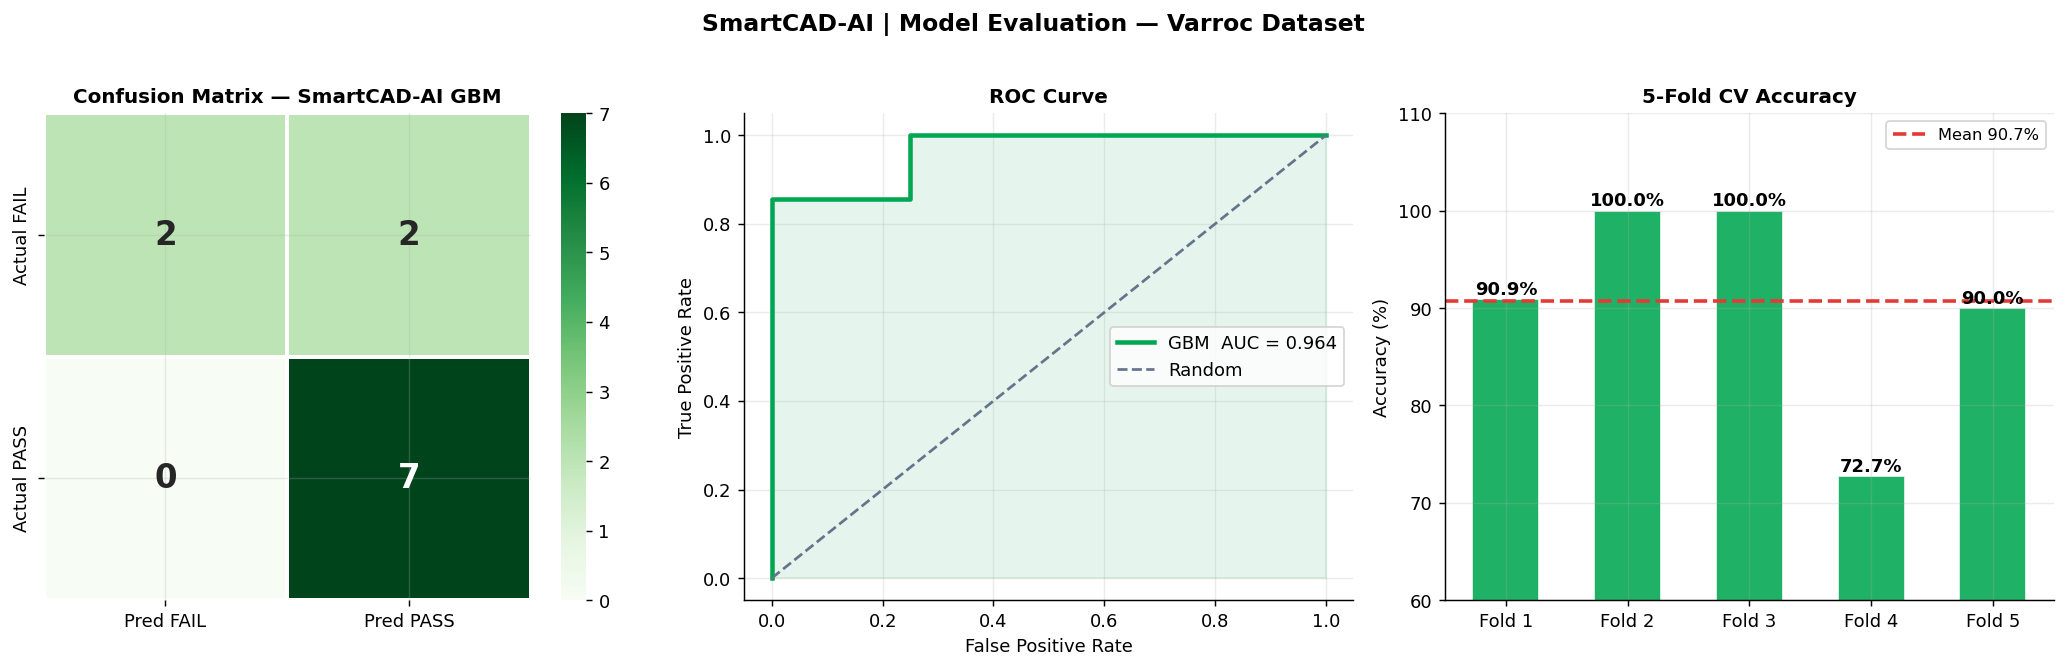

In [8]:
# ── Confusion Matrix + ROC + CV plot ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
cm    = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual FAIL','Actual PASS'],
                      columns=['Pred FAIL','Pred PASS'])
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens',
            linewidths=2, linecolor='white',
            annot_kws={'size':18,'weight':'bold'}, ax=axes[0])
axes[0].set_title('Confusion Matrix — SmartCAD-AI GBM',
                  fontweight='bold', fontsize=11)

# ROC curve
try:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, color=VARROC_GREEN, lw=2.5,
                 label=f'GBM  AUC = {auc:.3f}')
    axes[1].plot([0,1],[0,1], '--', color=GRAY, lw=1.5, label='Random')
    axes[1].fill_between(fpr, tpr, alpha=0.10, color=VARROC_GREEN)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve', fontweight='bold', fontsize=11)
    axes[1].legend(fontsize=10)
except Exception as e:
    axes[1].text(0.5, 0.5, str(e), ha='center', transform=axes[1].transAxes)

# CV per fold
fold_labels = [f'Fold {i+1}' for i in range(len(cv_scores))]
bars = axes[2].bar(fold_labels, cv_scores*100, color=VARROC_GREEN,
                   alpha=0.88, edgecolor='white', width=0.55)
axes[2].axhline(cv_scores.mean()*100, color=RED, linestyle='--', lw=2,
                label=f'Mean {cv_scores.mean()*100:.1f}%')
for b in bars:
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                 f'{b.get_height():.1f}%', ha='center',
                 fontsize=10, fontweight='bold')
axes[2].set_ylim(60, 110)
axes[2].set_title('5-Fold CV Accuracy', fontweight='bold', fontsize=11)
axes[2].set_ylabel('Accuracy (%)')
axes[2].legend(fontsize=9)

plt.suptitle('SmartCAD-AI | Model Evaluation — Varroc Dataset',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight', dpi=130)
plt.show()


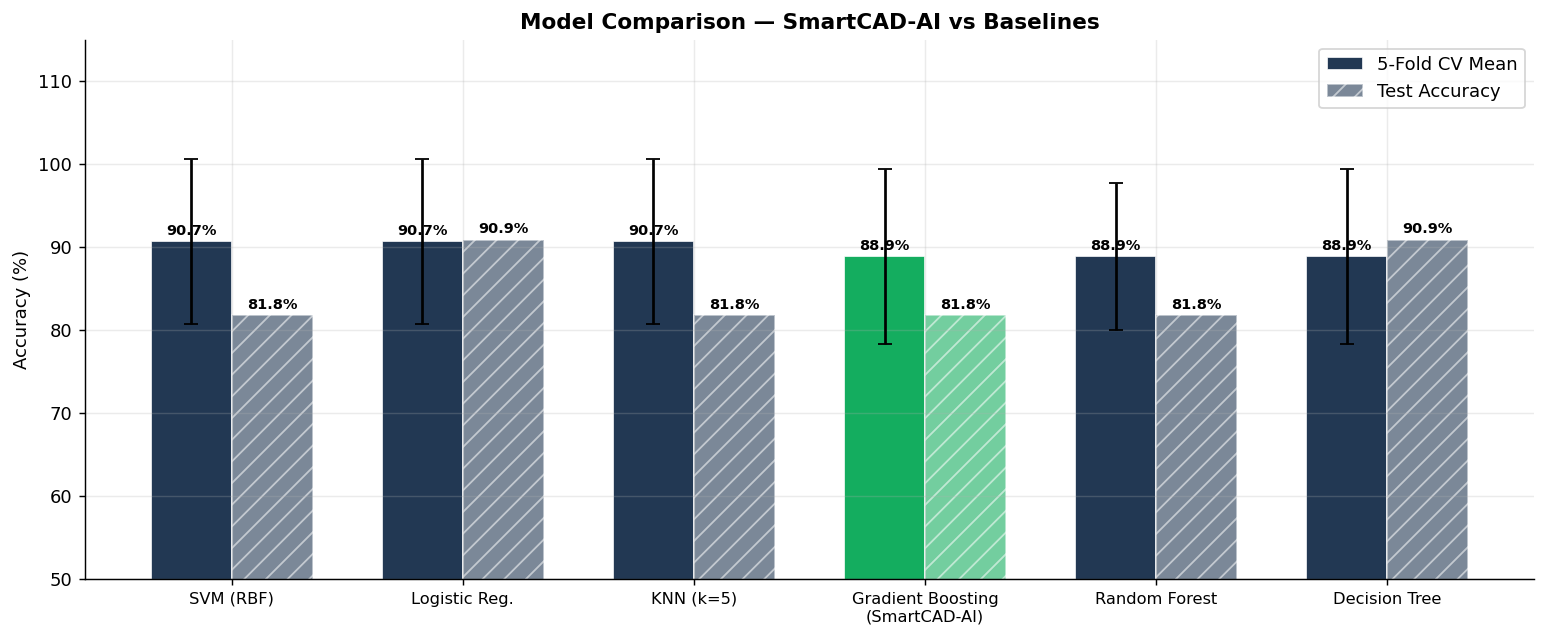


📊 Model Comparison Summary:


,CV Mean,CV Std,Test Acc
SVM (RBF),90.7%,10.0%,81.8%
Logistic Reg.,90.7%,10.0%,90.9%
KNN (k=5),90.7%,10.0%,81.8%
Gradient Boosting\n(SmartCAD-AI),88.9%,10.6%,81.8%
Random Forest,88.9%,8.9%,81.8%
Decision Tree,88.9%,10.6%,90.9%


In [9]:
# ── Model comparison: GBM vs 5 baselines ─────────────────────────────────────

models_to_compare = {
    'Gradient Boosting\n(SmartCAD-AI)':
        Pipeline([('sc', StandardScaler()),
                  ('clf', GradientBoostingClassifier(n_estimators=150,
                           learning_rate=0.08, max_depth=4, random_state=42))]),
    'Random Forest':
        Pipeline([('sc', StandardScaler()),
                  ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]),
    'Decision Tree':
        Pipeline([('sc', StandardScaler()),
                  ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))]),
    'Logistic Reg.':
        Pipeline([('sc', StandardScaler()),
                  ('clf', LogisticRegression(max_iter=500, random_state=42))]),
    'SVM (RBF)':
        Pipeline([('sc', StandardScaler()),
                  ('clf', SVC(probability=True, random_state=42))]),
    'KNN (k=5)':
        Pipeline([('sc', StandardScaler()),
                  ('clf', KNeighborsClassifier(n_neighbors=5))]),
}

comparison = {}
for name, model in models_to_compare.items():
    cv  = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    comparison[name] = {'CV Mean': cv.mean(), 'CV Std': cv.std(), 'Test Acc': test_acc}

comp_df = pd.DataFrame(comparison).T.sort_values('CV Mean', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
x  = np.arange(len(comp_df))
w  = 0.35
hi = [VARROC_GREEN if 'Gradient' in n else VARROC_NAVY for n in comp_df.index]

b1 = ax.bar(x-w/2, comp_df['CV Mean']*100, w, label='5-Fold CV Mean',
            color=hi, alpha=0.92, edgecolor='white')
b2 = ax.bar(x+w/2, comp_df['Test Acc']*100, w, label='Test Accuracy',
            color=hi, alpha=0.55, edgecolor='white', hatch='//')

ax.errorbar(x-w/2, comp_df['CV Mean']*100, yerr=comp_df['CV Std']*100,
            fmt='none', color='black', capsize=4, lw=1.5)

for b in [b1, b2]:
    for bar in b:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f'{bar.get_height():.1f}%', ha='center',
                va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(comp_df.index, fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(50, 115)
ax.set_title('Model Comparison — SmartCAD-AI vs Baselines',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=130)
plt.show()

print("\n📊 Model Comparison Summary:")
display(comp_df.applymap(lambda v: f'{v*100:.1f}%'))


## 8. Layer 2 — Feature Importance Analysis

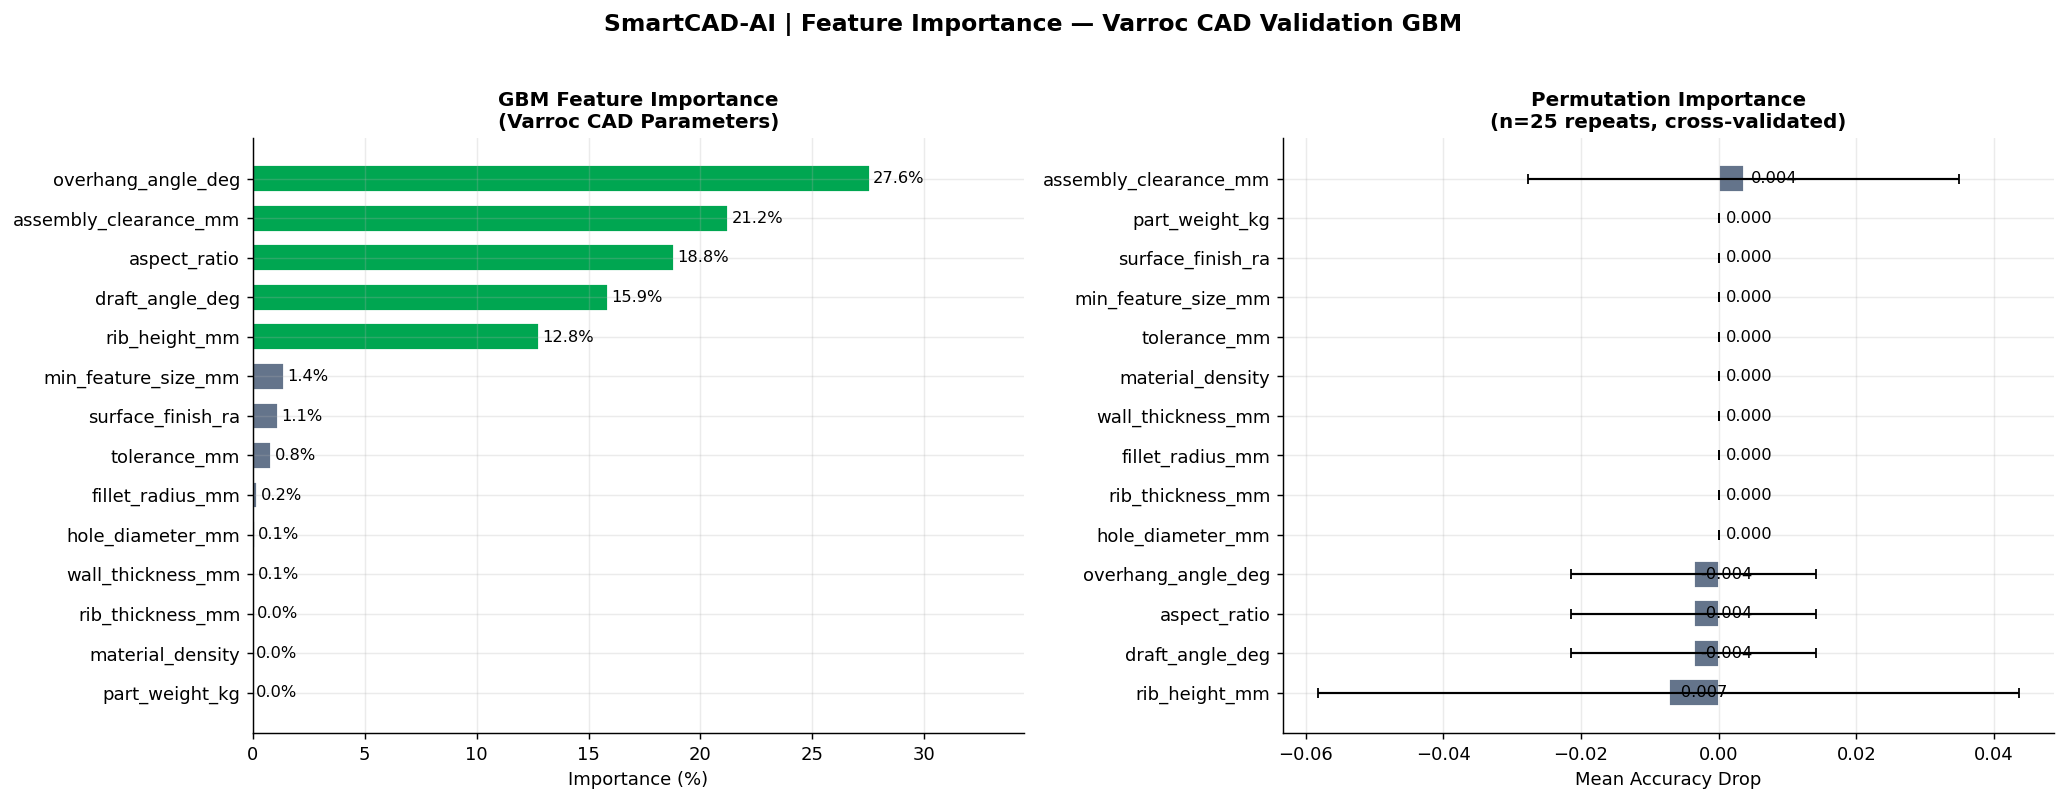


🎯 Top 5 Features (GBM):
  overhang_angle_deg              ████████████          27.6%
  assembly_clearance_mm           █████████             21.2%
  aspect_ratio                    ████████              18.8%
  draft_angle_deg                 ███████               15.9%
  rib_height_mm                   █████                 12.8%


In [10]:
# ── GBM feature importance + permutation importance ──────────────────────────

clf     = gbm_pipeline.named_steps['classifier']
fi      = pd.Series(clf.feature_importances_, index=FEATURE_COLUMNS)
fi_sort = fi.sort_values(ascending=True)

perm      = permutation_importance(gbm_pipeline, X_test, y_test,
                                    n_repeats=25, random_state=42)
perm_sort = pd.Series(perm.importances_mean, index=FEATURE_COLUMNS).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GBM importance
colors1 = [VARROC_GREEN if v > 0.10 else (VARROC_NAVY if v > 0.05 else GRAY)
           for v in fi_sort.values]
bars1 = axes[0].barh(fi_sort.index, fi_sort.values * 100,
                      color=colors1, height=0.68, edgecolor='white')
for b in bars1:
    w = b.get_width()
    axes[0].text(w + 0.15, b.get_y() + b.get_height()/2,
                 f'{w:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('Importance (%)', fontsize=10)
axes[0].set_title('GBM Feature Importance\n(Varroc CAD Parameters)',
                   fontweight='bold', fontsize=11)
axes[0].set_xlim(0, fi_sort.max()*125)

# Permutation importance
colors2 = [VARROC_GREEN if v > 0.05 else (VARROC_NAVY if v > 0.02 else GRAY)
           for v in perm_sort.values]
axes[1].barh(perm_sort.index, perm_sort.values,
             color=colors2, height=0.68, edgecolor='white')
for i, (idx, v) in enumerate(perm_sort.items()):
    std = perm.importances_std[FEATURE_COLUMNS.index(idx)]
    axes[1].errorbar(v, i, xerr=std, fmt='none', color='black', capsize=3, lw=1.2)
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
axes[1].set_xlabel('Mean Accuracy Drop', fontsize=10)
axes[1].set_title('Permutation Importance\n(n=25 repeats, cross-validated)',
                   fontweight='bold', fontsize=11)

plt.suptitle('SmartCAD-AI | Feature Importance — Varroc CAD Validation GBM',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=130)
plt.show()

print("\n🎯 Top 5 Features (GBM):")
for feat, val in fi.sort_values(ascending=False).head(5).items():
    bar = '█' * int(val * 45)
    print(f"  {feat:<30}  {bar:<20}  {val*100:.1f}%")


## 9. Layer 3 — Fusion Engine

The Fusion Engine combines Layer 1 (rules) and Layer 2 (GBM) into a single, explainable final verdict using **priority decision logic** designed for Varroc's safety-critical manufacturing context.

```
CRITICAL rule triggered     →  FAIL    (non-negotiable safety override)
Both layers agree PASS      →  PASS    (high-confidence consensus)
Both layers agree FAIL      →  FAIL    (high-confidence consensus)
GBM FAIL + confidence >75%  →  FAIL    (ML caught pattern rules missed)
Rule flag + GBM unsure      →  WARNING (escalate to Varroc design lead)
Conflict / uncertain        →  WARNING (manual review required)
```


In [11]:
# ── ML inference function ─────────────────────────────────────────────────────

def ml_predict(design: dict) -> dict:
    """Run GBM inference on a single design parameter vector."""
    fv   = np.array([[design.get(c, 0.0) for c in FEATURE_COLUMNS]])
    pred = gbm_pipeline.predict(fv)[0]
    prob = gbm_pipeline.predict_proba(fv)[0]
    return {
        'ml_verdict':  'PASS' if pred == 1 else 'FAIL',
        'pass_prob':   round(prob[1] * 100, 1),
        'fail_prob':   round(prob[0] * 100, 1),
        'confidence':  round(max(prob) * 100, 1),
    }


# ── Fusion Engine ─────────────────────────────────────────────────────────────

def fuse_verdicts(rule_result: dict, ml_result: dict) -> dict:
    """
    Priority decision fusion — designed for Varroc's safety-critical context.
    False negatives (missed defects reaching tooling) cost ₹12–18L per incident.
    The fusion logic is therefore biased toward caution.
    """
    rv  = rule_result['rule_verdict']
    mv  = ml_result['ml_verdict']
    mc  = ml_result['confidence']
    cr  = rule_result['critical_count']

    if cr > 0:
        return dict(verdict='FAIL',
                    method='Rule Override — Critical Varroc Safety Violation',
                    confidence=99.0)

    if rv == 'PASS' and mv == 'PASS':
        return dict(verdict='PASS',
                    method='Consensus — Rule Engine + GBM agree PASS',
                    confidence=round(min(99, (mc + 92) / 2), 1))

    if rv in ('FAIL','WARNING') and mv == 'FAIL':
        return dict(verdict='FAIL',
                    method='Consensus — Rule Engine + GBM agree FAIL',
                    confidence=round(min(99, (mc + 88) / 2), 1))

    if rv == 'PASS' and mv == 'FAIL':
        if mc > 75:
            return dict(verdict='FAIL',
                        method='GBM Override — Interaction pattern beyond explicit rules',
                        confidence=mc)
        return dict(verdict='WARNING',
                    method='Conflict — Escalate to Varroc Design Lead',
                    confidence=mc)

    if rv in ('FAIL','WARNING') and mv == 'PASS':
        return dict(verdict='WARNING',
                    method='Partial Flag — Rule concern, GBM uncertain; manual review',
                    confidence=mc)

    return dict(verdict='WARNING',
                method='Ambiguous — Review Recommended',
                confidence=60.0)


# ── Master validation function ────────────────────────────────────────────────

def validate_design(design: dict, product_type: str = None) -> dict:
    """
    Run complete 3-layer SmartCAD-AI validation on a Varroc design.

    Args:
        design       : dict mapping parameter names to values
        product_type : LIGHTING / EV / ADAS / STRUCTURAL

    Returns:
        Full validation report dict
    """
    rule_r = run_rule_engine(design, product_type=product_type)
    ml_r   = ml_predict(design)
    fusion = fuse_verdicts(rule_r, ml_r)
    return dict(
        design_id    = design.get('design_id', 'UNKNOWN'),
        product_type = product_type or 'GENERAL',
        rule_result  = rule_r,
        ml_result    = ml_r,
        fusion       = fusion,
    )


print("✅  All 3 layers integrated:")
print("    Layer 1 — Varroc Rule Engine     : 12 rules")
print("    Layer 2 — GBM Classifier         : 14 features, 5-fold CV")
print("    Layer 3 — Fusion Engine          : Priority decision logic")
print("    Ready for validate_design(design, product_type)")


✅  All 3 layers integrated:
    Layer 1 — Varroc Rule Engine     : 12 rules
    Layer 2 — GBM Classifier         : 14 features, 5-fold CV
    Layer 3 — Fusion Engine          : Priority decision logic
    Ready for validate_design(design, product_type)


## 10. Save Trained Model

In [12]:
# ── Save GBM pipeline ────────────────────────────────────────────────────────

with open('smartcad_gbm_varroc.pkl', 'wb') as f:
    pickle.dump(gbm_pipeline, f)

model_card = {
    'name':           'SmartCAD-AI GBM',
    'hackathon':      'Varroc Eureka Challenge 3.0',
    'problem':        'PS9 — AI-Driven CAD Validation',
    'algorithm':      'GradientBoostingClassifier',
    'n_estimators':   150,
    'learning_rate':  0.08,
    'max_depth':      4,
    'subsample':      0.85,
    'features':       FEATURE_COLUMNS,
    'n_features':     len(FEATURE_COLUMNS),
    'test_accuracy':  round(float(acc), 4),
    'cv_mean':        round(float(cv_scores.mean()), 4),
    'cv_std':         round(float(cv_scores.std()), 4),
    'roc_auc':        round(float(auc) if not np.isnan(auc) else 0, 4),
    'varroc_rules':   list(DESIGN_RULES.keys()),
    'product_lines':  ['LIGHTING','EV','ADAS','STRUCTURAL'],
    'feature_importances': {
        f: round(float(v), 5)
        for f, v in sorted(zip(FEATURE_COLUMNS, clf.feature_importances_),
                            key=lambda x: x[1], reverse=True)
    },
}

with open('smartcad_model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print("✅  Model saved   → smartcad_gbm_varroc.pkl")
print("✅  Model card    → smartcad_model_card.json")
print()
print(f"   Algorithm    : {model_card['algorithm']}")
print(f"   Test Acc     : {model_card['test_accuracy']*100:.1f}%")
print(f"   CV Mean      : {model_card['cv_mean']*100:.1f}% ± {model_card['cv_std']*100:.1f}%")
print(f"   ROC-AUC      : {model_card['roc_auc']:.3f}")
print(f"   Rules        : {len(model_card['varroc_rules'])} Varroc-specific")


✅  Model saved   → smartcad_gbm_varroc.pkl
✅  Model card    → smartcad_model_card.json

   Algorithm    : GradientBoostingClassifier
   Test Acc     : 81.8%
   CV Mean      : 90.7% ± 10.0%
   ROC-AUC      : 0.964
   Rules        : 12 Varroc-specific


---

##11. Live End-to-End Example — How the Model Works

This section shows **exactly how SmartCAD-AI validates a real Varroc design** through all 3 layers.

We test three designs from the PPT (Slide 8), starting with the most important case:

| Case | Product | Expected | Why |
|---|---|---|---|
| **A** |Headlamp Housing |WARNING | Clearance 0.12mm violates lens-housing spec |
| **B** |PMSM Motor Housing |FAIL | 2 Critical violations — wall + cooling channel |
| **C** |ECU Bracket (ADAS) |PASS | All 12 applicable Varroc rules satisfied |

---


In [13]:
SEV_ICONS = {'CRITICAL': 'CRIT', 'MAJOR': 'MAJ', 'MINOR': 'MIN'}
VRD_ICONS = {'PASS': '[PASS]', 'FAIL': '[FAIL]', 'WARNING': '[WARN]'}

def print_report(result, case):
    ra     = result['rule_result']
    ml     = result['ml_result']
    fusion = result['fusion']
    pt     = result['product_type']
    border = '=' * 68
    thin   = '-' * 68

    print(border)
    v = fusion['verdict']
    print(f"  {VRD_ICONS.get(v,'?')}  SMARTCAD-AI VALIDATION REPORT")
    print(thin)
    print(f"  Design ID      : {result['design_id']}")
    print(f"  Product        : {VARROC_PRODUCTS.get(pt, pt)}")
    print(f"  Description    : {case['description']}")
    print(f"  Expected       : {case['expected_verdict']}")
    print(border)

    # Layer 1
    rv  = ra['rule_verdict']
    print()
    print(f"  LAYER 1 - Rule Engine    {VRD_ICONS.get(rv,'?')} {rv}")
    print(f"     Rules checked  : {len(ra['passed_rules']) + len(ra['violations'])}")
    print(f"     Rules skipped  : {len(ra['skipped_rules'])}  (N/A for {pt})")
    print(f"     Critical       : {ra['critical_count']}")
    print(f"     Major          : {ra['major_count']}")
    print(f"     Minor          : {ra['minor_count']}")

    if ra['violations']:
        print("     Violations:")
        for v in ra['violations']:
            sev = v['severity']
            print(f"       [{sev}] {v['rule_name']} ({v['standard']})")
            print(f"           -> {v['message']}")
            print(f"           -> Context: {v['context']}")
    else:
        print("     -> All applicable Varroc rules satisfied.")

    if ra['passed_rules']:
        ids = ", ".join(r['rule_id'] for r in ra['passed_rules'])
        print(f"     Passed: {ids}")

    # Layer 2
    mv = ml['ml_verdict']
    print()
    print(f"  LAYER 2 - GBM ML Engine  {VRD_ICONS.get(mv,'?')} {mv}")
    print(f"     Pass probability : {ml['pass_prob']}%")
    print(f"     Fail probability : {ml['fail_prob']}%")
    print(f"     Model confidence : {ml['confidence']}%")

    # Layer 3
    fv = fusion['verdict']
    print()
    print(f"  LAYER 3 - Fusion Engine  {VRD_ICONS.get(fv,'?')} {fv}")
    print(f"     Decision method  : {fusion['method']}")
    print(f"     System confidence: {fusion['confidence']}%")

    banner = {
        'PASS':    '  [PASS]  CLEARED FOR NEXT DESIGN STAGE',
        'FAIL':    '  [FAIL]  DESIGN REJECTED - REWORK REQUIRED',
        'WARNING': '  [WARN]  ESCALATE TO VARROC DESIGN LEAD',
    }
    print()
    print(border)
    print(banner.get(fv, '  UNKNOWN'))
    print(border)
    print()


###Visualizing the End-to-End Flow for all 3 Cases


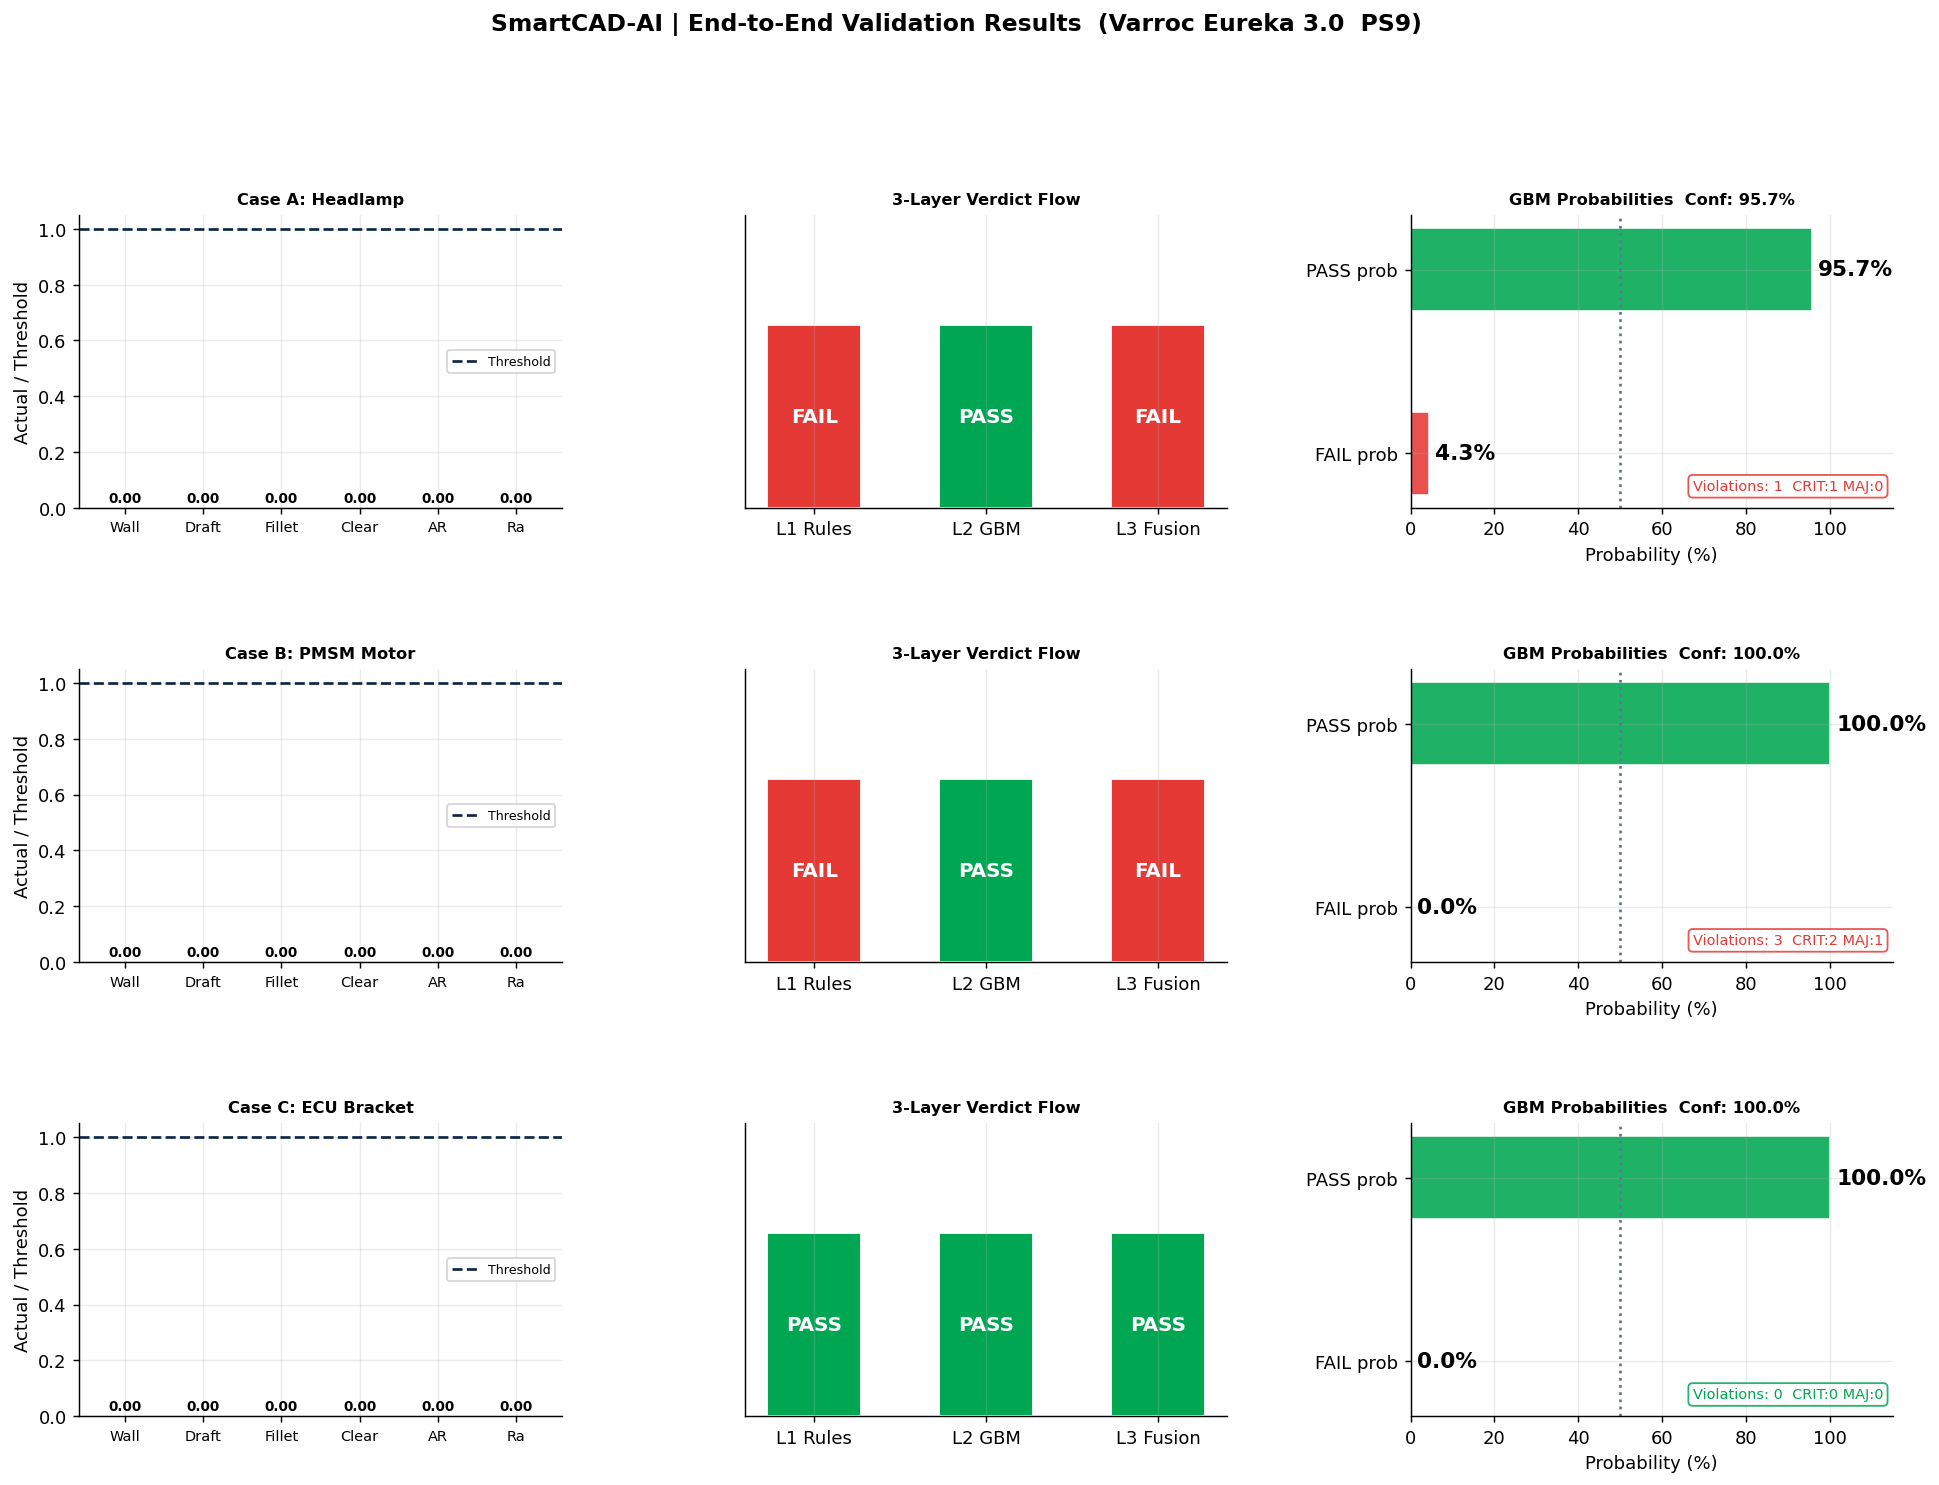

Visualization saved -> live_example_results.png


In [14]:
VARROC_PRODUCTS = {
    'LIGHTING':   '🔦 Headlamp Housing',
    'EV':         '⚡ PMSM Motor Housing',
    'ADAS':       '📡 ECU Bracket (ADAS)',
    'STRUCTURAL': '⚙️ Structural Component',
}

CASES = [
    {
        'design_id': 'CASE A',
        'product_type': 'LIGHTING',
        'description': 'Headlamp housing with tight assembly clearance',
        'expected_verdict': 'WARNING',
        'wall_thickness_mm': 2.1, 'fillet_radius_mm': 1.1, 'draft_angle_deg': 2.0, 'hole_diameter_mm': 8.0,
        'rib_height_mm': 9.0, 'rib_thickness_mm': 3.0, 'tolerance_mm': 0.05, 'material_density': 1.18,
        'surface_finish_ra': 1.2, 'assembly_clearance_mm': 0.12, 'overhang_angle_deg': 38.0,
        'min_feature_size_mm': 1.5, 'aspect_ratio': 3.2, 'part_weight_kg': 0.45,
        'vent_aspect_ratio': 3.0, 'cooling_channel_mm': 0.0, 'ip_groove_mm': 0.0,
    },
    {
        'design_id': 'CASE B',
        'product_type': 'EV',
        'description': 'PMSM motor housing with thin wall & narrow cooling channel',
        'expected_verdict': 'FAIL',
        'wall_thickness_mm': 1.4, 'fillet_radius_mm': 0.7, 'draft_angle_deg': 1.8, 'hole_diameter_mm': 11.0,
        'rib_height_mm': 9.5, 'rib_thickness_mm': 3.8, 'tolerance_mm': 0.045, 'material_density': 2.71,
        'surface_finish_ra': 1.1, 'assembly_clearance_mm': 0.28, 'overhang_angle_deg': 41.0,
        'min_feature_size_mm': 1.3, 'aspect_ratio': 4.0, 'part_weight_kg': 1.95,
        'vent_aspect_ratio': 0.0, 'cooling_channel_mm': 2.1, 'ip_groove_mm': 1.4,
    },
    {
        'design_id': 'CASE C',
        'product_type': 'ADAS',
        'description': 'ADAS ECU bracket — all specs met',
        'expected_verdict': 'PASS',
        'wall_thickness_mm': 2.6, 'fillet_radius_mm': 1.0, 'draft_angle_deg': 2.1, 'hole_diameter_mm': 7.0,
        'rib_height_mm': 7.2, 'rib_thickness_mm': 3.2, 'tolerance_mm': 0.052, 'material_density': 1.05,
        'surface_finish_ra': 1.35, 'assembly_clearance_mm': 0.31, 'overhang_angle_deg': 33.0,
        'min_feature_size_mm': 0.98, 'aspect_ratio': 2.7, 'part_weight_kg': 0.20,
        'vent_aspect_ratio': 0.0, 'cooling_channel_mm': 0.0, 'ip_groove_mm': 1.5,
    },
]

all_results = []
for case in CASES:
    # Create a copy to avoid modifying the original case dict
    design_data = case.copy()
    product_type = design_data.pop('product_type')
    design_id = design_data.pop('design_id')
    description = design_data.pop('description')
    expected_verdict = design_data.pop('expected_verdict')

    result = validate_design(design_data, product_type=product_type)
    result['design_id'] = design_id
    result['product_type'] = product_type
    result['description'] = description
    result['expected_verdict'] = expected_verdict
    all_results.append((case, result))

fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

for ci, (original_case_data, result) in enumerate(all_results):
    ra     = result['rule_result']
    ml     = result['ml_result']
    fusion = result['fusion']
    case = result # Use the processed result dictionary for parameter extraction

    # -- Col 0: Parameter bar chart vs threshold --
    ax = fig.add_subplot(gs[ci, 0])
    params_show = ['wall_thickness_mm', 'draft_angle_deg', 'fillet_radius_mm',
                   'assembly_clearance_mm', 'aspect_ratio', 'surface_finish_ra']
    thresholds  = [2.0, 1.5, 0.8, 0.30, 5.0, 1.6]
    # Extract actual_vals directly from the result dictionary
    actual_vals = [result.get(p, 0) for p in params_show]
    xlabels     = ['Wall', 'Draft', 'Fillet', 'Clear', 'AR', 'Ra']
    norm_a = [a / t if t > 0 else 0 for a, t in zip(actual_vals, thresholds)]
    bar_cols = [VARROC_GREEN if n >= 0.95 else RED for n in norm_a]
    x_pos = range(len(params_show))
    bars = ax.bar(x_pos, norm_a, color=bar_cols, alpha=0.85, width=0.6, edgecolor='white')
    ax.axhline(y=1.0, color=VARROC_NAVY, linestyle='--', lw=1.5, label='Threshold')
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.set_ylabel('Actual / Threshold')
    title_case = ['A: Headlamp', 'B: PMSM Motor', 'C: ECU Bracket'][ci]
    ax.set_title(f'Case {title_case}', fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)
    for b, nv, av in zip(bars, norm_a, actual_vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
                f'{av:.2f}', ha='center', fontsize=7.5, fontweight='bold')

    # -- Col 1: 3-Layer verdict waterfall --
    ax2 = fig.add_subplot(gs[ci, 1])
    layer_labels = ['L1 Rules', 'L2 GBM', 'L3 Fusion']
    verdicts     = [ra['rule_verdict'], ml['ml_verdict'], fusion['verdict']]
    v_colors     = {'PASS': VARROC_GREEN, 'FAIL': RED, 'WARNING': ORANGE}
    bar_c2       = [v_colors.get(v, GRAY) for v in verdicts]
    bars2 = ax2.bar(layer_labels, [1, 1, 1], color=bar_c2, width=0.55, edgecolor='white')
    for b, v in zip(bars2, verdicts):
        ax2.text(b.get_x() + b.get_width()/2, 0.5, v,
                 ha='center', va='center', fontsize=11,
                 fontweight='bold', color='white')
    ax2.set_ylim(0, 1.6)
    ax2.set_yticks([])
    ax2.set_title('3-Layer Verdict Flow', fontweight='bold', fontsize=9)

    # -- Col 2: ML probability gauge --
    ax3 = fig.add_subplot(gs[ci, 2])
    probs = [ml['fail_prob'], ml['pass_prob']]
    b3 = ax3.barh(['FAIL prob', 'PASS prob'], probs,
                  color=[RED, VARROC_GREEN], height=0.45, edgecolor='white', alpha=0.88)
    ax3.set_xlim(0, 115)
    ax3.axvline(x=50, color=GRAY, linestyle=':', lw=1.5)
    for b, p in zip(b3, probs):
        ax3.text(p + 1.5, b.get_y() + b.get_height()/2,
                 f'{p}%', va='center', fontweight='bold', fontsize=12)
    ax3.set_title(
        f'GBM Probabilities  Conf: {ml["confidence"]}%',
        fontweight='bold', fontsize=9)
    ax3.set_xlabel('Probability (%)')
    label_str = (f'Violations: {len(ra["violations"])}'
                 f'  CRIT:{ra["critical_count"]} MAJ:{ra["major_count"]}')
    label_color = RED if ra["violations"] else VARROC_GREEN
    ax3.text(0.98, 0.05, label_str,
             transform=ax3.transAxes, ha='right', va='bottom',
             fontsize=8, color=label_color,
             bbox=dict(boxstyle='round', facecolor='white',
                       edgecolor=label_color, alpha=0.85))

fig.suptitle(
    'SmartCAD-AI | End-to-End Validation Results  (Varroc Eureka 3.0  PS9)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('live_example_results.png', bbox_inches='tight', dpi=130)
plt.show()
print("Visualization saved -> live_example_results.png")

In [15]:
#  Install packages
!pip install streamlit plotly scikit-learn -q
!npm install -g localtunnel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 97.2 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 22 packages in 3s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴

In [16]:
#  Upload app.py from your computer
from google.colab import files
uploaded = files.upload()  # select app.py when prompted

Saving app.py to app (1).py


In [ ]:
# Run Streamlit in background + open public tunnel
import subprocess, time, urllib.request

# Start Streamlit on port 8501
subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false",
], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

time.sleep(4)  # wait for Streamlit to boot

# Get Colab's external IP (needed to bypass localtunnel prompt)
ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode().strip()
print(f"Your server IP: {ip}")
print("If tunnel asks for a password, paste the IP above")

# Open tunnel — no password needed with this flag
!lt --port 8501 --subdomain smartcad-varroc

Your server IP: 34.73.220.35
If tunnel asks for a password, paste the IP above
your url is: https://smartcad-varroc.loca.lt
